# Convolutional Neural Networks para trabajar con CIFAR-10



##  Dataset CIFAR-10 y tarea asociada

**CIFAR-10** es un conjunto de datos de clasificación de imágenes a color con **60,000** imágenes de tamaño **32×32** píxeles, **3 canales (RGB)** y **10 clases**.

- Entrenamiento: **50,000**
- Prueba (test): **10,000**
- 10 clases


## Objetivo de la práctica

** Probar el desempeño de las CNN** y analizar sus **fortalezas y debilidades** al trabajar con imágenes.

### Fortalezas típicas de CNN (para imágenes)
- Explotan **localidad espacial**: patrones como bordes/texturas se detectan con filtros pequeños (p.ej. 3×3).
- **Compartición de pesos**: un mismo filtro se aplica a toda la imagen → menos parámetros y mejor generalización.
- Construyen representaciones **jerárquicas**: bordes → texturas → partes → objetos.
- Mayor **robustez a traslaciones** pequeñas y variaciones locales (especialmente con pooling/strides).

### Debilidades / limitaciones
- Si se destruye la estructura espacial, las convoluciones dejan de ser informativas.
- Requieren decisiones de diseño: profundidad, ancho, normalización, regularización, etc.
- Pueden sobreajustar si son muy grandes o si el entrenamiento no está bien regulado.


In [2]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np


import os
import torch.nn as nn
import torch.optim as optim
import pandas as pd

SEED = 42
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device 

'cuda'

In [3]:
# Normalización típica CIFAR-10 (RGB)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std)
])

train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
len(train_full), len(test_set), class_names

(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

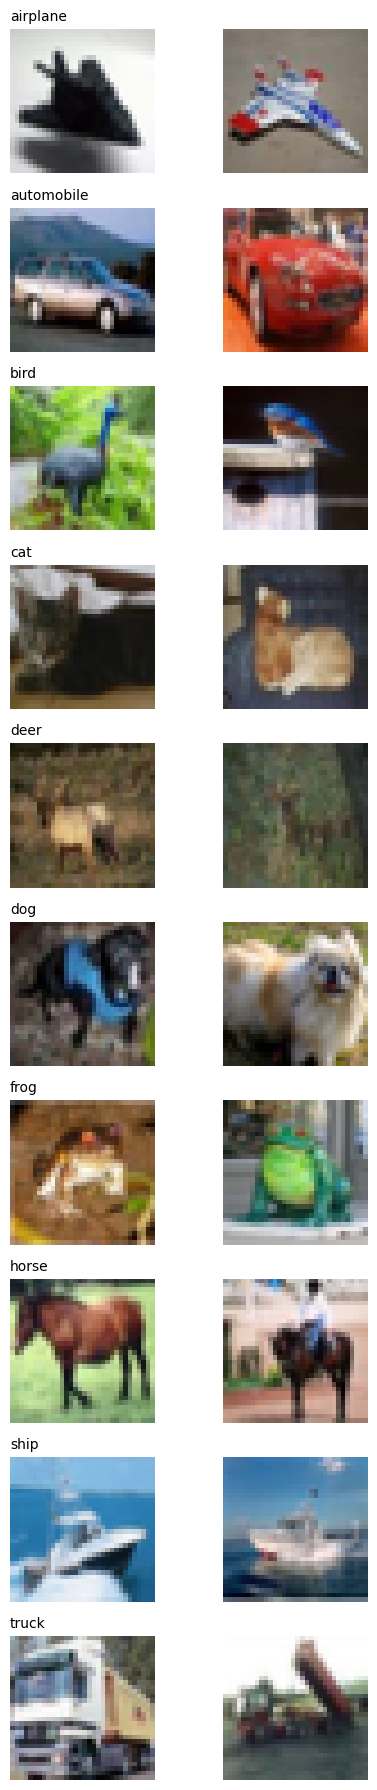

In [4]:
# Des-normalizar solo para visualizar
mean = torch.tensor(cifar10_mean).view(3,1,1)
std  = torch.tensor(cifar10_std).view(3,1,1)

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)

# Tomar 2 ejemplos por clase
examples = {c: [] for c in range(10)}
for img, label in train_full:
    if len(examples[label]) < 2:
        examples[label].append(img)
    if all(len(examples[c]) == 2 for c in range(10)):
        break

fig, axes = plt.subplots(10, 2, figsize=(5, 18))
for c in range(10):
    for j in range(2):
        ax = axes[c, j]
        img = denormalize(examples[c][j])
        ax.imshow(img.permute(1,2,0))
        ax.axis("off")
        if j == 0:
            ax.set_title(class_names[c], loc="left", fontsize=10)

plt.tight_layout()
plt.show()

## Antecedente: copia "flat" para redes Fully-Connected (MLP)

Para MLP, convertimos cada imagen de (3,32,32) a un vector (3072).


In [5]:
x0, y0 = train_full[0]
print("Original:", x0.shape)
print("Flat:", torch.flatten(x0).shape)

Original: torch.Size([3, 32, 32])
Flat: torch.Size([3072])


In [ ]:
class FlatWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]              
        x = torch.flatten(x, start_dim=0)  
        return x, y

flat_train_full = FlatWrapper(train_full)
flat_test_set = FlatWrapper(test_set)

xf, yf = flat_train_full[0]
print("Flat sample shape:", xf.shape, "label:", yf)

Flat sample shape: torch.Size([3072]) label: 6


## Partición entrenamiento/validación (10%) para original y flat 
Creamos una sola partición de índices y la aplicamos a ambos datasets.


In [7]:
val_fraction = 0.10
n_total = len(train_full)
n_val = int(n_total * val_fraction)
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g).tolist()

train_idx = perm[:n_train]
val_idx = perm[n_train:]

# Subsets ORIGINAL
train_set = Subset(train_full, train_idx)
val_set   = Subset(train_full, val_idx)

# Subsets FLAT (misma partición)
flat_train_set = Subset(flat_train_full, train_idx)
flat_val_set   = Subset(flat_train_full, val_idx)

print("Original train/val:", len(train_set), len(val_set))
print("Flat train/val:", len(flat_train_set), len(flat_val_set))


Original train/val: 45000 5000
Flat train/val: 45000 5000


In [ ]:
BATCH_SIZE = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_WORKERS = 0  # Evita cuelgues en Jupyter/Windows
PIN_MEMORY = True if DEVICE == "cuda" else False

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

flat_train_loader = DataLoader(flat_train_set, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

flat_val_loader   = DataLoader(flat_val_set, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

flat_test_loader  = DataLoader(flat_test_set, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

xb, yb = next(iter(train_loader))
xfb, yfb = next(iter(flat_train_loader))

print("Batch original:", xb.shape, yb.shape)
print("Batch flat:", xfb.shape, yfb.shape)


Batch original: torch.Size([256, 3, 32, 32]) torch.Size([256])
Batch flat: torch.Size([256, 3072]) torch.Size([256])


## Actividad: MLP (tu propuesta) + 5 topologías CNN + 1 CNN propuesta 

### Instrucción A — MLP
Usa tu MLP de la práctica anterior y entrénalo con:
- `flat_train_loader`, `flat_val_loader`, `flat_test_loader`

### Instrucción B — 5 CNN propuestas
Implementa y entrena las siguientes topologías usando:
- `train_loader`, `val_loader`, `test_loader`

**Hiperparámetros (base):**
- Épocas: 30 
- Optimizador: AdamW
- LR: 1e-3
- Weight decay: 1e-4
- Loss: CrossEntropyLoss
- Batch size: 256
- Activación: ReLU
- Regularización: Dropout y/o BatchNorm

# Descripción detallada de las arquitecturas CNN propuestas

En todos los casos la entrada es una imagen de **CIFAR-10** con dimensión:

\[
(3, 32, 32)
\]

donde:
- 3 = canales RGB  
- 32×32 = resolución espacial  

---

## 🔹 CNN-1 (Arquitectura muy básica)

### Estructura

1. **Convolución:**  
   `Conv(3 → 32, kernel=3×3, padding=1)`  
2. **Activación:** ReLU  
3. **Pooling:** `MaxPool(2×2)`  
4. **Clasificador:**  
   `Flatten → FC(32×16×16 → 10)`

### Flujo dimensional

| Etapa | Dimensión |
|--------|-----------|
| Entrada | (3, 32, 32) |
| Conv + ReLU | (32, 32, 32) |
| MaxPool | (32, 16, 16) |
| Flatten | 8192 |
| FC | 10 |

### Interpretación

- Aprende bordes y patrones simples.
- Es la CNN más sencilla posible.
- Funciona como baseline convolucional.

---

## 🔹 CNN-2 (Dos bloques convolucionales)

### Estructura

**Bloque 1**
- Conv(3 → 32, 3×3, padding=1)
- ReLU
- MaxPool(2×2)

**Bloque 2**
- Conv(32 → 64, 3×3, padding=1)
- ReLU
- MaxPool(2×2)

**Clasificador**
- Flatten
- FC(64×8×8 → 10)

### Flujo dimensional

| Etapa | Dimensión |
|--------|-----------|
| Entrada | (3, 32, 32) |
| Bloque 1 | (32, 16, 16) |
| Bloque 2 | (64, 8, 8) |
| Flatten | 4096 |
| FC | 10 |

### Interpretación

- Primer bloque: detecta bordes y texturas.
- Segundo bloque: combina patrones para detectar estructuras más complejas.
- Mayor capacidad representacional que CNN-1.

---

## 🔹 CNN-3 (Dos convoluciones por bloque)

### Estructura

**Bloque 1**
- Conv(3 → 32) + ReLU  
- Conv(32 → 32) + ReLU  
- MaxPool  

**Bloque 2**
- Conv(32 → 64) + ReLU  
- Conv(64 → 64) + ReLU  
- MaxPool  

**Clasificador**
- Flatten  
- FC(64×8×8 → 10)  
- Dropout (opcional)

### Interpretación

- Se aplican dos convoluciones antes de reducir la resolución.
- Permite aprender patrones más ricos antes del pooling.
- Mayor profundidad → mayor capacidad de modelado.
- Dropout ayuda a reducir sobreajuste.

---

## 🔹 CNN-4 (Más profunda + Batch Normalization)

### Estructura

**Bloque 1**
- Conv → BatchNorm → ReLU  
- Conv → BatchNorm → ReLU  
- MaxPool  

**Bloque 2**
- Conv → BatchNorm → ReLU  
- Conv → BatchNorm → ReLU  
- MaxPool  

**Bloque 3**
- Conv(64 → 128) → BatchNorm → ReLU  
- MaxPool  

**Clasificador**
- Flatten  
- FC(128×4×4 → 256)  
- ReLU  
- Dropout  
- FC(256 → 10)

### Flujo dimensional aproximado

| Etapa | Dimensión |
|--------|-----------|
| Entrada | (3, 32, 32) |
| Bloque 1 | (32, 16, 16) |
| Bloque 2 | (64, 8, 8) |
| Bloque 3 | (128, 4, 4) |
| Flatten | 2048 |
| FC | 256 → 10 |

### Interpretación

- Mucho más profunda.
- BatchNorm estabiliza el entrenamiento.
- Dropout reduce sobreajuste.
- Mayor capacidad → mayor riesgo de sobreajuste si no se regula.

---

## 🔹 CNN-5 (Con Global Average Pooling)

### Estructura

- Conv(3 → 64) + ReLU  
- Conv(64 → 128) + ReLU  
- Conv(128 → 256) + ReLU  
- Global Average Pooling  
- FC(256 → 10)

### ¿Qué hace Global Average Pooling?

Convierte:

\[
(256, H, W)
\]

en:

\[
(256)
\]

promediando cada mapa de activación completo.

### Interpretación

- Reduce drásticamente la cantidad de parámetros.
- Cada canal final representa una característica global.
- Mejora generalización.
- Reduce riesgo de sobreajuste comparado con grandes capas fully connected.

---

### Instrucción C — CNN propuesta por el estudiante
Propón 1 CNN adicional que mejore a las anteriores (precisión, parámetros, estabilidad, etc.).

### Qué almacenar (para cada modelo: MLP + 6 CNN)
- Loss y accuracy en **entrenamiento**
- Loss y accuracy en **prueba**

### Tabla obligatoria
Comparar todos los modelos con:
- Resumen arquitectura
- **# parámetros entrenables**
- Loss/Acc train
- Loss/Acc test


In [11]:

os.makedirs("loss", exist_ok=True)

class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Linear(32 * 16 * 16, 10)
    def forward(self, x):
        return self.classifier(torch.flatten(self.conv(x), 1))

class CNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Linear(64 * 8 * 8, 10)
    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

class CNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(64 * 8 * 8, 10))
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class CNN4(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(128 * 4 * 4, 256), nn.ReLU(), 
            nn.Dropout(0.5), nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class CNN5(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(256, 10)
    def forward(self, x):
        return self.classifier(torch.flatten(self.features(x), 1))

In [ ]:
def train_model(model, name, train_loader, val_loader, test_loader, epochs=30, eval_every=5, optimizer=1e-4):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=optimizer)
    criterion = nn.CrossEntropyLoss()

    history = {'Epoch': [], 'Train Loss': [], 'Train Acc': [], 'Val Loss': [], 'Val Acc': []}
    
    def evaluate(loader):
        model.eval()
        correct, total, total_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        return total_loss / total, correct / total

    print(f"\n{'='*50}\nIniciando entrenamiento de {name}\n{'='*50}")
    
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            
        # Evaluar con VALIDACIÓN durante el entrenamiento
        if (epoch + 1) % eval_every == 0 or (epoch + 1) == epochs:
            train_loss, train_acc = evaluate(train_loader)
            val_loss, val_acc = evaluate(val_loader)  
            
            history['Epoch'].append(epoch + 1)
            history['Train Loss'].append(train_loss)
            history['Train Acc'].append(train_acc)
            history['Val Loss'].append(val_loss)
            history['Val Acc'].append(val_acc)
            
            print(f"Época [{epoch+1}/{epochs}] | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # === EVALUACIÓN FINAL CON TEST ===
    print(f"\n--- Evaluando {name} en el conjunto de TEST final ---")
    final_test_loss, final_test_acc = evaluate(test_loader)
    print(f"Test Final -> Loss: {final_test_loss:.4f} | Acc: {final_test_acc:.4f}")

    df_history = pd.DataFrame(history)
    excel_path = f"loss/{name}_history.xlsx"
    df_history.to_excel(excel_path, index=False)
    print(f"-> Historial guardado en: {excel_path}")
    
    # Gráficas
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss', marker='o')
    plt.plot(history['Epoch'], history['Val Loss'], label='Val Loss', marker='o')
    plt.title(f'{name} - Evolución de Pérdida (Loss)')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Acc'], label='Train Acc', marker='o')
    plt.plot(history['Epoch'], history['Val Acc'], label='Val Acc', marker='o')
    plt.title(f'{name} - Evolución de Precisión (Accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
            
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {
        "Modelo": name,
        "Parámetros": params,
        "Train Loss": round(train_loss, 4), "Train Acc": round(train_acc, 4),
        "Val Loss": round(val_loss, 4), "Val Acc": round(val_acc, 4),
        "Test Loss": round(final_test_loss, 4), "Test Acc": round(final_test_acc, 4)
    } 




Iniciando entrenamiento de CNN-1
Época [5/30] | Train Loss: 0.9111 Acc: 0.6915 | Val Loss: 1.0861 Acc: 0.6236
Época [10/30] | Train Loss: 0.7772 Acc: 0.7328 | Val Loss: 1.0661 Acc: 0.6404
Época [15/30] | Train Loss: 0.6624 Acc: 0.7777 | Val Loss: 1.0544 Acc: 0.6536
Época [20/30] | Train Loss: 0.5938 Acc: 0.8014 | Val Loss: 1.0951 Acc: 0.6516
Época [25/30] | Train Loss: 0.5442 Acc: 0.8157 | Val Loss: 1.1371 Acc: 0.6516
Época [30/30] | Train Loss: 0.4860 Acc: 0.8374 | Val Loss: 1.1627 Acc: 0.6480

--- Evaluando CNN-1 en el conjunto de TEST final ---
Test Final -> Loss: 1.1652 | Acc: 0.6438
-> Historial guardado en: loss/CNN-1_history.xlsx


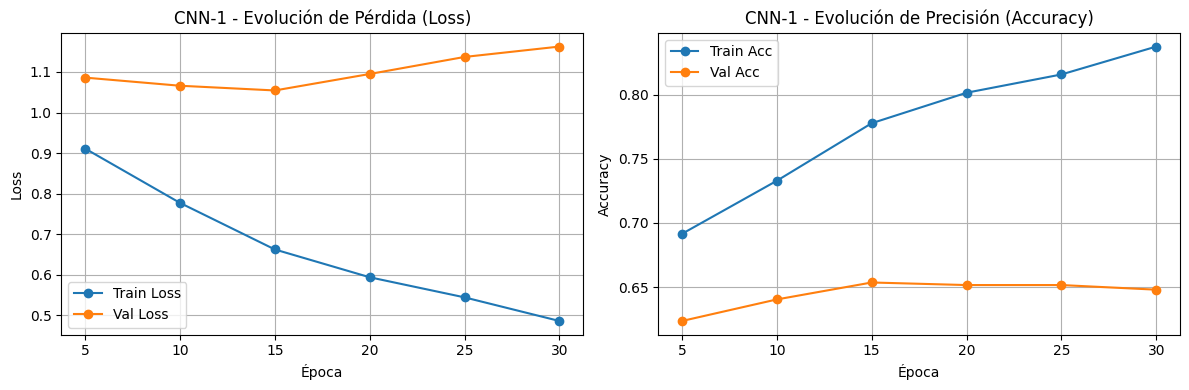


Iniciando entrenamiento de CNN-2
Época [5/30] | Train Loss: 0.7902 Acc: 0.7289 | Val Loss: 0.9364 Acc: 0.6818
Época [10/30] | Train Loss: 0.6161 Acc: 0.7916 | Val Loss: 0.9008 Acc: 0.7030
Época [15/30] | Train Loss: 0.4953 Acc: 0.8327 | Val Loss: 0.9320 Acc: 0.7010
Época [20/30] | Train Loss: 0.3943 Acc: 0.8671 | Val Loss: 0.9865 Acc: 0.6970
Época [25/30] | Train Loss: 0.3009 Acc: 0.9006 | Val Loss: 1.0485 Acc: 0.7076
Época [30/30] | Train Loss: 0.2461 Acc: 0.9184 | Val Loss: 1.1800 Acc: 0.6998

--- Evaluando CNN-2 en el conjunto de TEST final ---
Test Final -> Loss: 1.2031 | Acc: 0.6929
-> Historial guardado en: loss/CNN-2_history.xlsx


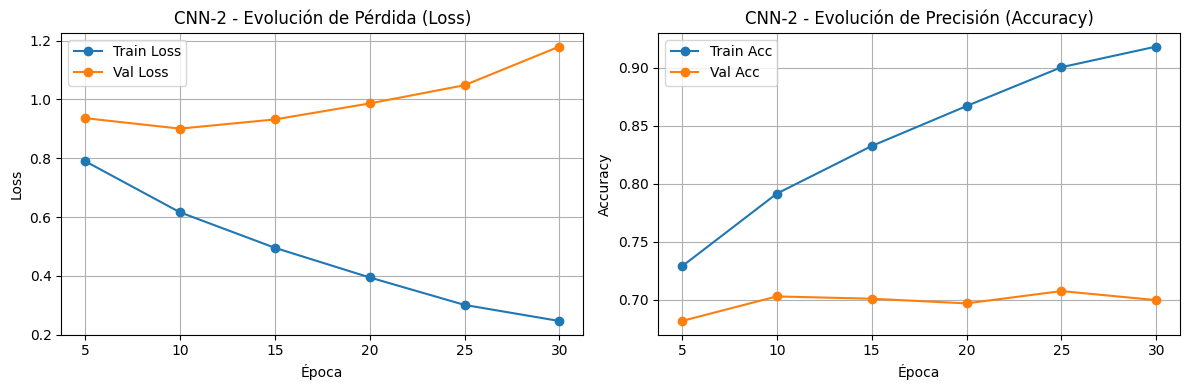


Iniciando entrenamiento de CNN-3
Época [5/30] | Train Loss: 0.7365 Acc: 0.7505 | Val Loss: 0.8172 Acc: 0.7162
Época [10/30] | Train Loss: 0.5221 Acc: 0.8272 | Val Loss: 0.6688 Acc: 0.7642
Época [15/30] | Train Loss: 0.4045 Acc: 0.8660 | Val Loss: 0.6161 Acc: 0.7854
Época [20/30] | Train Loss: 0.3419 Acc: 0.8912 | Val Loss: 0.6029 Acc: 0.7896
Época [25/30] | Train Loss: 0.3038 Acc: 0.9054 | Val Loss: 0.5973 Acc: 0.7928
Época [30/30] | Train Loss: 0.2319 Acc: 0.9312 | Val Loss: 0.5716 Acc: 0.8008

--- Evaluando CNN-3 en el conjunto de TEST final ---
Test Final -> Loss: 0.5981 | Acc: 0.8008
-> Historial guardado en: loss/CNN-3_history.xlsx


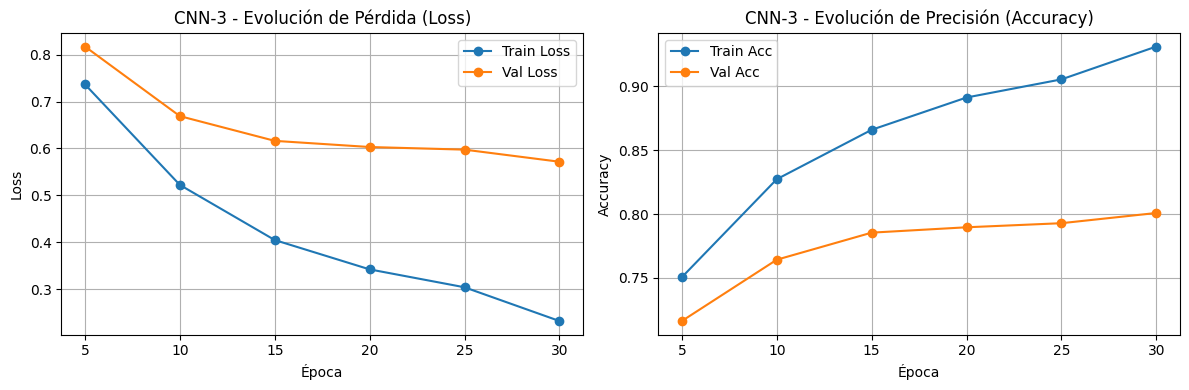


Iniciando entrenamiento de CNN-4
Época [5/30] | Train Loss: 0.5214 Acc: 0.8167 | Val Loss: 0.6304 Acc: 0.7788
Época [10/30] | Train Loss: 0.3253 Acc: 0.8840 | Val Loss: 0.5911 Acc: 0.7900
Época [15/30] | Train Loss: 0.2832 Acc: 0.9019 | Val Loss: 0.7301 Acc: 0.7796
Época [20/30] | Train Loss: 0.1351 Acc: 0.9511 | Val Loss: 0.7389 Acc: 0.8024
Época [25/30] | Train Loss: 0.0549 Acc: 0.9830 | Val Loss: 0.6814 Acc: 0.8220
Época [30/30] | Train Loss: 0.0583 Acc: 0.9804 | Val Loss: 0.8373 Acc: 0.8116

--- Evaluando CNN-4 en el conjunto de TEST final ---
Test Final -> Loss: 0.8443 | Acc: 0.8135
-> Historial guardado en: loss/CNN-4_history.xlsx


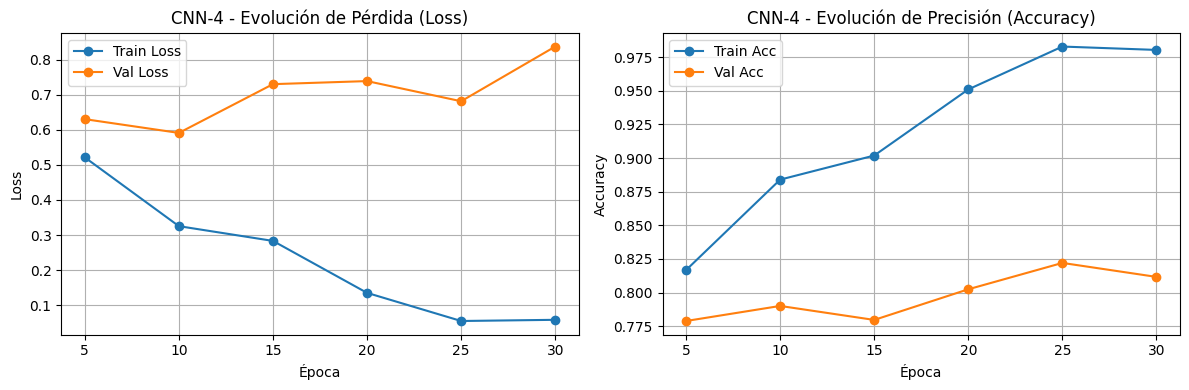


Iniciando entrenamiento de CNN-5
Época [5/30] | Train Loss: 1.3310 Acc: 0.5216 | Val Loss: 1.3470 Acc: 0.5110
Época [10/30] | Train Loss: 1.1670 Acc: 0.5906 | Val Loss: 1.1845 Acc: 0.5828
Época [15/30] | Train Loss: 1.0721 Acc: 0.6218 | Val Loss: 1.0995 Acc: 0.6044
Época [20/30] | Train Loss: 0.9784 Acc: 0.6576 | Val Loss: 1.0220 Acc: 0.6330
Época [25/30] | Train Loss: 0.9592 Acc: 0.6610 | Val Loss: 1.0062 Acc: 0.6326
Época [30/30] | Train Loss: 0.8982 Acc: 0.6888 | Val Loss: 0.9710 Acc: 0.6580

--- Evaluando CNN-5 en el conjunto de TEST final ---
Test Final -> Loss: 0.9545 | Acc: 0.6732
-> Historial guardado en: loss/CNN-5_history.xlsx


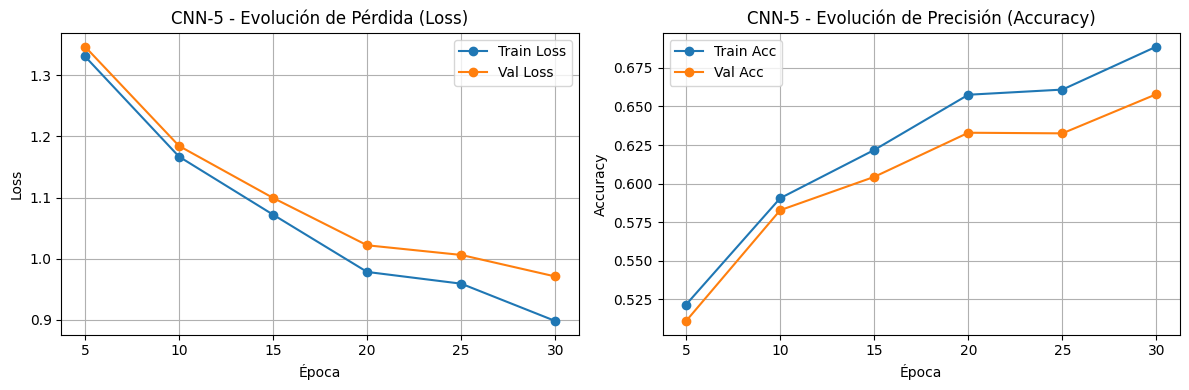


TABLA COMPARATIVA FINAL


,Modelo,Parámetros,Train Loss,Train Acc,Val Loss,Val Acc,Test Loss,Test Acc
0,CNN-1,82826,0.4860,0.8374,1.1627,0.6480,1.1652,0.6438
1,CNN-2,60362,0.2461,0.9184,1.1800,0.6998,1.2031,0.6929
2,CNN-3,106538,0.2319,0.9312,0.5716,0.8008,0.5981,0.8008
3,CNN-4,667178,0.0583,0.9804,0.8373,0.8116,0.8443,0.8135
4,CNN-5,373386,0.8982,0.6888,0.9710,0.6580,0.9545,0.6732


In [ ]:

cnn_models = {
    "CNN-1": CNN1(), 
    "CNN-2": CNN2(), 
    "CNN-3": CNN3(), 
    "CNN-4": CNN4(), 
    "CNN-5": CNN5()
}

results = []

for name, model in cnn_models.items():
    res = train_model(model, name, train_loader, val_loader, test_loader, epochs=30, eval_every=5)
    results.append(res)

print("\n" + "="*50)
print("TABLA COMPARATIVA FINAL")
print("="*50)
df_results = pd.DataFrame(results)
display(df_results)

## MLP

In [ ]:

SEED = 42
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std)
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std)
])


train_full_aug = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
train_full_clean = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_test)

test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

val_fraction = 0.10
n_total = len(train_full_aug)
n_val = int(n_total * val_fraction)
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g).tolist()

train_idx = perm[:n_train]
val_idx = perm[n_train:]

train_set = Subset(train_full_aug, train_idx)
val_set   = Subset(train_full_clean, val_idx)

print(f"Tamaño Train: {len(train_set)} | Tamaño Val: {len(val_set)} | Tamaño Test: {len(test_set)}")

BATCH_SIZE = 256
NUM_WORKERS = 0  
PIN_MEMORY = True if device == "cuda" else False

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

Usando dispositivo: cuda
Tamaño Train: 45000 | Tamaño Val: 5000 | Tamaño Test: 10000


In [ ]:
class CIFAR_MLP2(nn.Module):
    def __init__(self, hidden_sizes, input_size=3072, num_classes=10, dropout_p=0.2):
        super(CIFAR_MLP2, self).__init__()
        layers = []
        in_dim = input_size
        
        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim)) 
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(p=dropout_p))
            
            in_dim = h_dim
        
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Aplanar la imagen de (N, 3, 32, 32) a (N, 3072)
        x = torch.flatten(x, start_dim=1) 
        return self.net(x)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    return loss_sum / total, 100 * correct / total

def train_model_augmented(config_name, hidden_sizes, train_loader, val_loader, test_loader, epochs=30):
    print(f"\n--- Entrenando {config_name} + DATA AUGMENTATION ---")
    
    model = CIFAR_MLP2(hidden_sizes, dropout_p=0.2).to(device)
    
    # NUEVO: Contar parámetros
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"-> Parámetros a entrenar: {params}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_val_loss, epoch_val_acc = evaluate(model, val_loader)
        
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        
        if (epoch+1) % 5 == 0 or (epoch+1) == epochs:
            print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

    # Gráfica
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss (Augmented)', marker='o', markersize=4)
    plt.plot(val_losses, label='Validation Loss (Clean)', marker='o', markersize=4)
    plt.title(f'Curva de Aprendizaje - {config_name}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\n{'='*50}\nRealizando Evaluaciones Finales...\n{'='*50}")
    
    final_train_loss, final_train_acc = evaluate(model, train_loader)
    final_val_loss, final_val_acc = evaluate(model, val_loader)
    test_loss, test_acc = evaluate(model, test_loader)
    
    resultado_final = {
        "Modelo": config_name,
        "Parámetros": params,
        "Train Loss": round(final_train_loss, 4),
        "Train Acc": round(final_train_acc, 4), 
        "Val Loss": round(final_val_loss, 4),
        "Val Acc": round(final_val_acc, 4),
        "Test Loss": round(test_loss, 4),
        "Test Acc": round(test_acc, 4),
        "Modelo_Entrenado": model 
    }
    
    print(f"\n{'='*80}\nTABLA DE RESULTADOS: {config_name}\n{'='*80}")
    

    df_res = pd.DataFrame([{k: v for k, v in resultado_final.items() if k != "Modelo_Entrenado"}])
    
    # Formateamos las columnas de Accuracy agregando el signo de porcentaje para mejor lectura
    df_res['Train Acc'] = df_res['Train Acc'].apply(lambda x: f"{x:.2f}%")
    df_res['Val Acc'] = df_res['Val Acc'].apply(lambda x: f"{x:.2f}%")
    df_res['Test Acc'] = df_res['Test Acc'].apply(lambda x: f"{x:.2f}%")
    
    try:
        from IPython.display import display
        display(df_res)
    except ImportError:
        print(df_res.to_string(index=False))
        
    return resultado_final


--- Entrenando MLP Propuesto + DATA AUGMENTATION ---
-> Parámetros a entrenar: 3809034
Epoch [5/30] Train Loss: 1.5106, Val Loss: 1.3867, Val Acc: 49.74%
Epoch [10/30] Train Loss: 1.4124, Val Loss: 1.2997, Val Acc: 52.82%
Epoch [15/30] Train Loss: 1.3507, Val Loss: 1.2420, Val Acc: 55.58%
Epoch [20/30] Train Loss: 1.3031, Val Loss: 1.2132, Val Acc: 56.56%
Epoch [25/30] Train Loss: 1.2668, Val Loss: 1.1876, Val Acc: 57.82%
Epoch [30/30] Train Loss: 1.2350, Val Loss: 1.1550, Val Acc: 59.14%


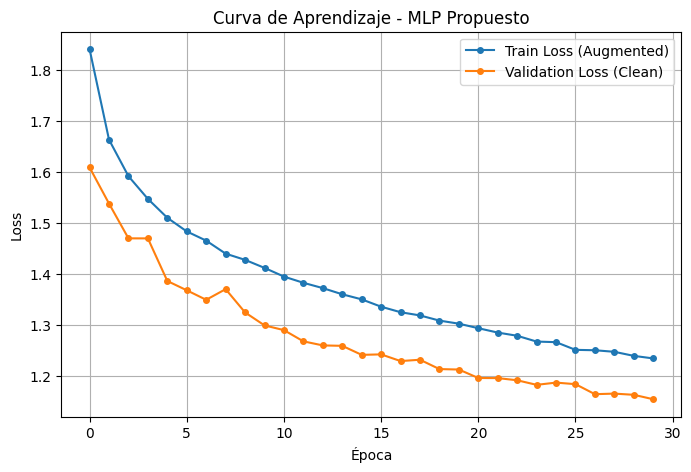


Realizando Evaluaciones Finales...

TABLA DE RESULTADOS: MLP Propuesto


,Modelo,Parámetros,Train Loss,Train Acc,Val Loss,Val Acc,Test Loss,Test Acc
0,MLP Propuesto,3809034,1.127,59.75%,1.155,59.14%,1.1471,59.13%



=== RESUMEN DE RESULTADOS ===


,Modelo,Parámetros,Train Loss,Train Acc,Val Loss,Val Acc,Test Loss,Test Acc,Modelo_Entrenado
0,MLP Propuesto,3809034,1.127,59.7533,1.155,59.14,1.1471,59.13,CIFAR_MLP2(\n (net): Sequential(\n (0): Li...


In [ ]:

configs = [
    {"name": "MLP Propuesto", "hidden_sizes": [1024, 512, 256]}
]

resultados = []

for conf in configs:
    res = train_model_augmented(
        config_name=conf["name"],
        hidden_sizes=conf["hidden_sizes"],
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=30  
    ) 
    resultados.append(res)

df_resultados = pd.DataFrame(resultados)
print("\n=== RESUMEN DE RESULTADOS ===")
display(df_resultados) # Usa print(df_resultados) si no estás en Jupyter Notebook

## CNN PROPUESTA

In [ ]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import Subset, DataLoader


train_transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])


train_full_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=train_transform_aug
)

train_set_aug = Subset(train_full_aug, train_idx)

train_loader_aug = DataLoader(
    train_set_aug, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

print(f"-> DataLoader de entrenamiento con Augmentation listo. Imágenes: {len(train_set_aug)}")

-> DataLoader de entrenamiento con Augmentation listo. Imágenes: 45000


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn 

def train_model(model, name, train_loader, val_loader, test_loader, epochs=30, eval_every=1):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    history = {'Epoch': [], 'Train Loss': [], 'Train Acc': [], 'Val Loss': [], 'Val Acc': []}

    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"-> Entrenando {name} con {params} parámetros...")
    
    def evaluate(loader):
        model.eval()
        correct, total, total_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        return total_loss / total, correct / total

    print(f"\n{'='*50}\nIniciando entrenamiento de {name}\n{'='*50}")
    
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()
            
        if (epoch + 1) % eval_every == 0 or (epoch + 1) == epochs:
            train_loss, train_acc = evaluate(train_loader)
            val_loss, val_acc = evaluate(val_loader) 
            
            history['Epoch'].append(epoch + 1)
            history['Train Loss'].append(train_loss)
            history['Train Acc'].append(train_acc)
            history['Val Loss'].append(val_loss)
            history['Val Acc'].append(val_acc)
            
            print(f"Época [{epoch+1}/{epochs}] | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    print(f"\n{'='*50}\nRealizando Evaluación Final en el Test Set (Imparcial)\n{'='*50}")
    test_loss, test_acc = evaluate(test_loader)
    print(f"-> TEST LOSS: {test_loss:.4f} | TEST ACCURACY: {test_acc:.4f}\n")

    # Guardar historial 
    os.makedirs("loss", exist_ok=True)
    df_history = pd.DataFrame(history)
    excel_path = f"loss/{name}_history.xlsx"
    df_history.to_excel(excel_path, index=False)
    print(f"-> Historial de entrenamiento guardado en: {excel_path}")
    
    # Gráficas
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['Epoch'], history['Train Loss'], label='Train Loss', marker='o')
    plt.plot(history['Epoch'], history['Val Loss'], label='Val Loss', marker='o') 
    plt.title(f'{name} - Evolución de Pérdida (Loss)')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['Epoch'], history['Train Acc'], label='Train Acc', marker='o')
    plt.plot(history['Epoch'], history['Val Acc'], label='Val Acc', marker='o') 
    plt.title(f'{name} - Evolución de Precisión (Accuracy)')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    resultado_final = {
        "Modelo": name,
        "Parámetros": params,
        "Train Loss": round(train_loss, 4), 
        "Train Acc": round(train_acc, 4),
        "Val Loss": round(val_loss, 4), 
        "Val Acc": round(val_acc, 4),
        "Test Loss": round(test_loss, 4), 
        "Test Acc": round(test_acc, 4),
        "Modelo_Entrenado": model 
    }
    
    print(f"\n{'='*80}\nTABLA DE RESULTADOS: {name}\n{'='*80}")
    
   
    df_res = pd.DataFrame([{k: v for k, v in resultado_final.items() if k != "Modelo_Entrenado"}])
    
    
    try:
        from IPython.display import display
        display(df_res)
    except ImportError:
        print(df_res.to_string(index=False))
            
    return resultado_final

In [ ]:
import torch
import torch.nn as nn

class CNN_Eficiente_GAP(nn.Module): 
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(  #
            # ==========================================
            # Bloque 1 
            # ==========================================
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            
            # ==========================================
            # Bloque 2
            # ==========================================
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # ==========================================
            # Bloque 3 
            # ==========================================
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
        )
        
        # CLASIFICADOR FINAL
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 8 * 8, 10) 
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

-> Entrenando CNN_Eficiente_GAP_Aug con 360522 parámetros...

Iniciando entrenamiento de CNN_Eficiente_GAP_Aug
Época [1/30] | Train Loss: 1.4805 Acc: 0.4614 | Val Loss: 1.4099 Acc: 0.4902
Época [2/30] | Train Loss: 1.1752 Acc: 0.5777 | Val Loss: 1.1050 Acc: 0.6132
Época [3/30] | Train Loss: 1.0284 Acc: 0.6336 | Val Loss: 0.9896 Acc: 0.6544
Época [4/30] | Train Loss: 0.8947 Acc: 0.6825 | Val Loss: 0.8721 Acc: 0.6936
Época [5/30] | Train Loss: 0.8482 Acc: 0.7023 | Val Loss: 0.8051 Acc: 0.7184
Época [6/30] | Train Loss: 0.8258 Acc: 0.7076 | Val Loss: 0.7900 Acc: 0.7190
Época [7/30] | Train Loss: 0.7271 Acc: 0.7463 | Val Loss: 0.7212 Acc: 0.7476
Época [8/30] | Train Loss: 0.7184 Acc: 0.7465 | Val Loss: 0.7079 Acc: 0.7492
Época [9/30] | Train Loss: 0.7273 Acc: 0.7484 | Val Loss: 0.7432 Acc: 0.7386
Época [10/30] | Train Loss: 0.6647 Acc: 0.7690 | Val Loss: 0.6395 Acc: 0.7770
Época [11/30] | Train Loss: 0.7560 Acc: 0.7370 | Val Loss: 0.7636 Acc: 0.7406
Época [12/30] | Train Loss: 0.6622 Acc: 

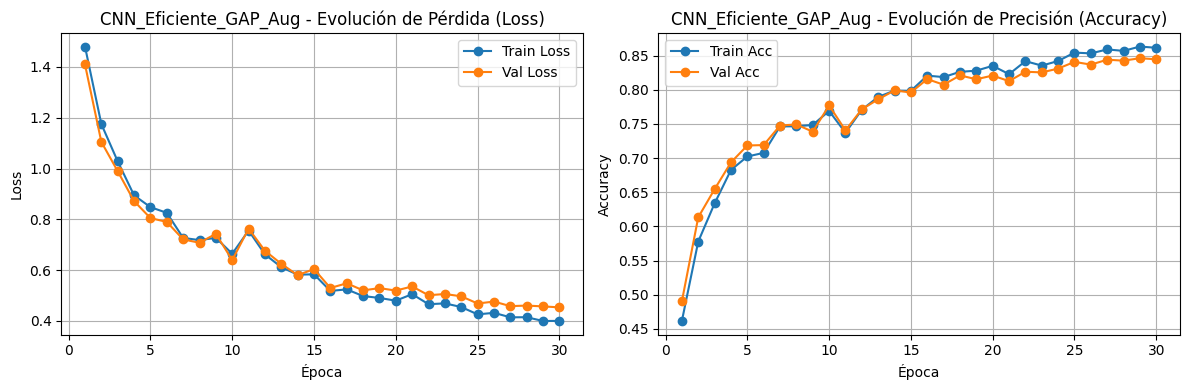


TABLA DE RESULTADOS: CNN_Eficiente_GAP_Aug


,Modelo,Parámetros,Train Loss,Train Acc,Val Loss,Val Acc,Test Loss,Test Acc
0,CNN_Eficiente_GAP_Aug,360522,0.4004,0.8614,0.4536,0.8446,0.4759,0.8371



TABLA COMPARATIVA FINAL


,Modelo,Parámetros,Train Loss,Train Acc,Val Loss,Val Acc,Test Loss,Test Acc,Modelo_Entrenado
0,CNN_Eficiente_GAP_Aug,360522,0.4004,0.8614,0.4536,0.8446,0.4759,0.8371,CNN_Eficiente_GAP(\n (features): Sequential(\...


In [77]:

cnn_models2 = {
    "CNN_Eficiente_GAP_Aug": CNN_Eficiente_GAP(), 
}

results = []

for name, model in cnn_models2.items():
    res = train_model(
        model=model, 
        name=name, 
        train_loader=train_loader_aug, 
        val_loader=val_loader, 
        test_loader=test_loader,  
        epochs=30, 
        eval_every=1
    )
    results.append(res)

print("\n" + "="*80)
print("TABLA COMPARATIVA FINAL")
print("="*80)
df_results = pd.DataFrame(results)
display(df_results)

## Interpretabilidad: filtros y mapas de activación 

Para cada CNN:
1. Visualiza algunos filtros de la primera capa (p.ej. 16 filtros).
2. Analiza mapas de activación para 2–3 imágenes en:
   - Primera capa/bloque
   - Un bloque intermedio
   - Última capa antes del clasificador

Incluye un análisis: qué detectan, cómo evoluciona la abstracción, etc.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Función auxiliar para mostrar la imagen original correctamente
def imshow_tensor(img_tensor):
    img = img_tensor.cpu().numpy()
    img = img / 2 + 0.5 
    img = np.clip(img, 0, 1)
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis('off')

# 1. Función para visualizar los filtros
def plot_filters(model, model_name):
    # Encontramos la primera capa convolucional iterando por los módulos
    first_conv = None
    for m in model.modules():
        if isinstance(m, torch.nn.Conv2d):
            first_conv = m
            break
            
    if first_conv is None: return
    
    weights = first_conv.weight.data.cpu()
    
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle(f'16 Filtros de la Capa 1 - {model_name}', fontsize=14)
    
    for i, ax in enumerate(axes.flatten()):
        if i < weights.shape[0]:
            f = weights[i]
            # Normalizamos de 0 a 1 para visualizar como imagen RGB
            f_min, f_max = f.min(), f.max()
            f_norm = (f - f_min) / (f_max - f_min + 1e-8)
            ax.imshow(f_norm.permute(1, 2, 0).numpy())
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 2. Función para visualizar mapas de activación
def plot_activation_maps(model, model_name, images_tensor):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    activations = []
    
    # Definimos un "gancho" para guardar la salida de las convoluciones
    def hook_fn(module, input, output):
        activations.append(output.cpu())
        
    hooks = []
    # Registramos el gancho en todas las capas Conv2d
    for m in model.modules():
        if isinstance(m, torch.nn.Conv2d):
            hooks.append(m.register_forward_hook(hook_fn))
            
    # Pasamos las imágenes por la red
    with torch.no_grad():
        _ = model(images_tensor.to(device))
        
    # Removemos los ganchos para no ensuciar el modelo
    for h in hooks: h.remove()
    
    num_convs = len(activations)
    if num_convs == 0: return
    
    # Seleccionamos qué capas mostrar: Primera, Intermedia (si hay) y Última
    layers_to_show = [0] 
    if num_convs > 2:
        layers_to_show.append(num_convs // 2) 
    if num_convs > 1:
        layers_to_show.append(num_convs - 1) 
        
    layer_titles = ["Primera Capa", "Capa Intermedia", "Última Capa Conv"]
    
    for img_idx in range(images_tensor.size(0)):
        print(f"\n{'-'*40}\n{model_name} | Analizando Imagen {img_idx + 1}\n{'-'*40}")
        plt.figure(figsize=(2, 2))
        imshow_tensor(images_tensor[img_idx])
        plt.title("Imagen Original", fontsize=10)
        plt.show()
        
        for i, layer_idx in enumerate(layers_to_show):
            # Obtenemos las activaciones de esta capa para la imagen actual
            act = activations[layer_idx][img_idx] 
            
            # Mostramos los primeros 4 canales para no saturar la pantalla
            num_channels = min(8, act.shape[0])
            title_idx = 0 if layer_idx == 0 else (2 if layer_idx == num_convs - 1 else 1)
            title = f"{layer_titles[title_idx]} (Conv {layer_idx+1})"
            
            fig, axes = plt.subplots(1, num_channels, figsize=(10, 3))
            fig.suptitle(title, fontsize=12)
            
            if num_channels == 1: axes = [axes]
            
            for c in range(num_channels):
                # Usamos el mapa de color 'viridis' (tonos verdes/azules/amarillos)
                axes[c].imshow(act[c].numpy(), cmap='viridis')
                axes[c].axis('off')
            plt.tight_layout()
            plt.show()



REPORTE DE INTERPRETABILIDAD: CNN-1


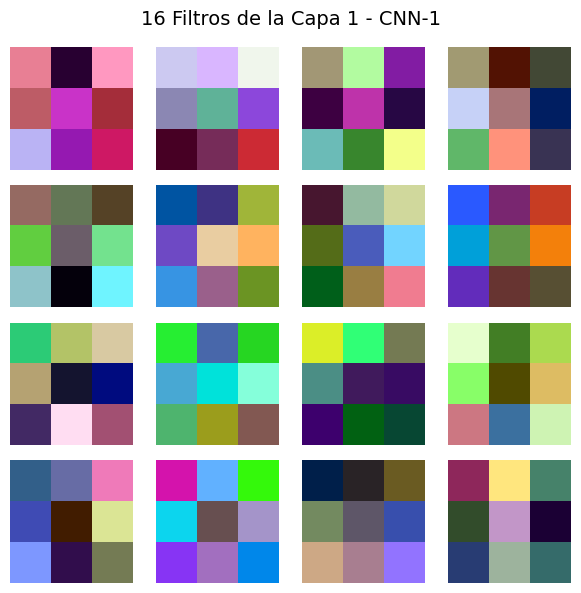


----------------------------------------
CNN-1 | Analizando Imagen 1
----------------------------------------


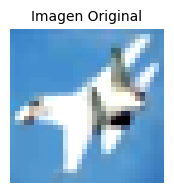

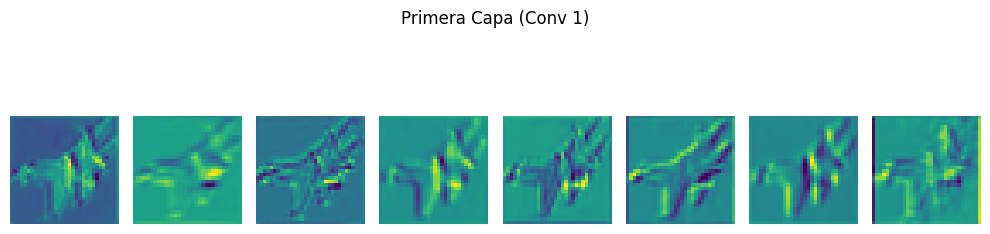


----------------------------------------
CNN-1 | Analizando Imagen 2
----------------------------------------


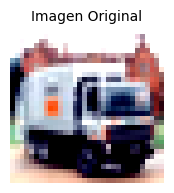

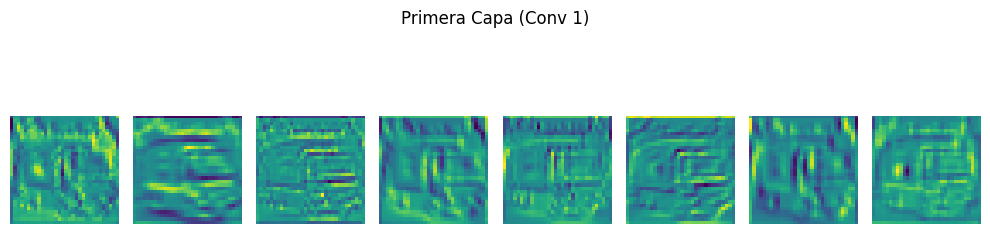



REPORTE DE INTERPRETABILIDAD: CNN-2


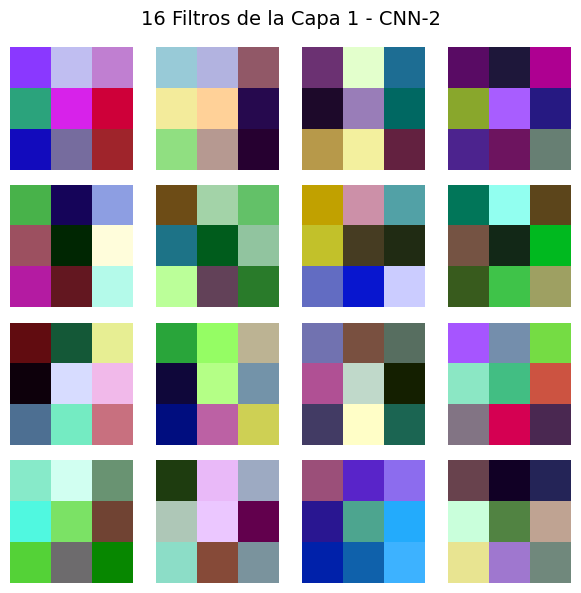


----------------------------------------
CNN-2 | Analizando Imagen 1
----------------------------------------


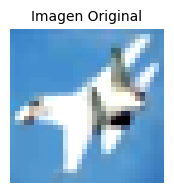

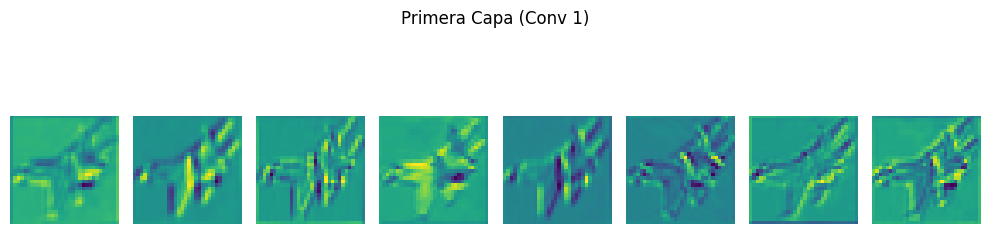

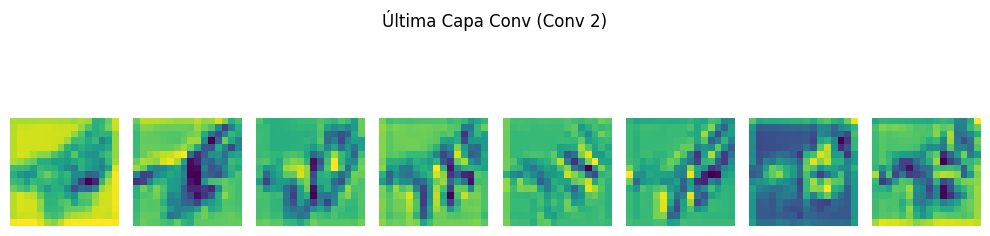


----------------------------------------
CNN-2 | Analizando Imagen 2
----------------------------------------


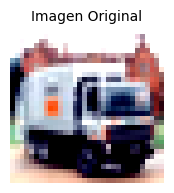

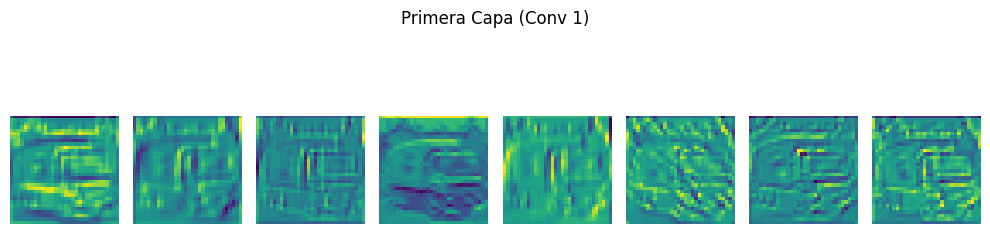

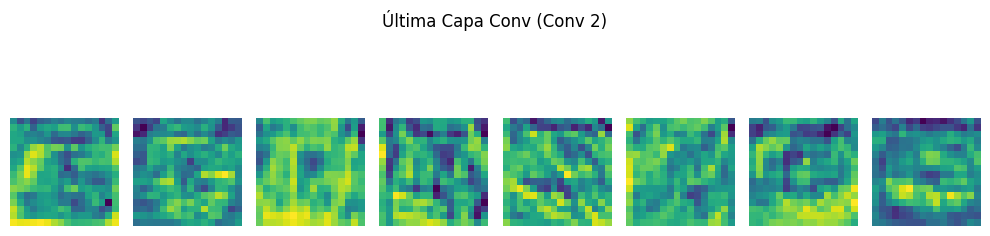



REPORTE DE INTERPRETABILIDAD: CNN-3


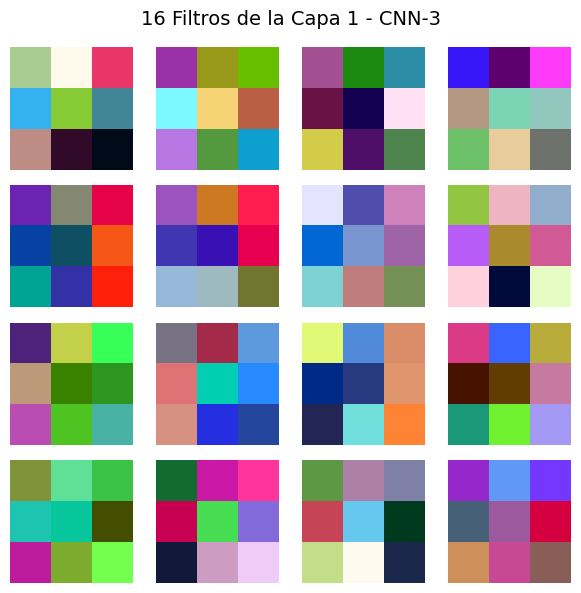


----------------------------------------
CNN-3 | Analizando Imagen 1
----------------------------------------


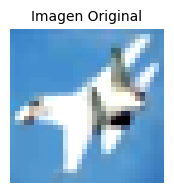

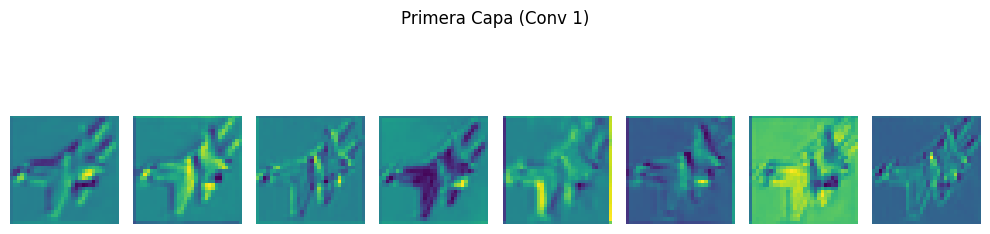

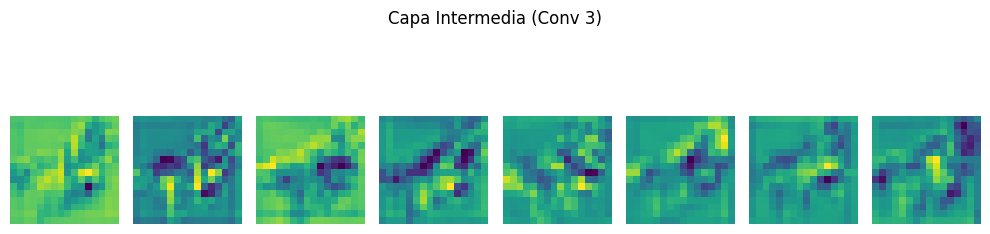

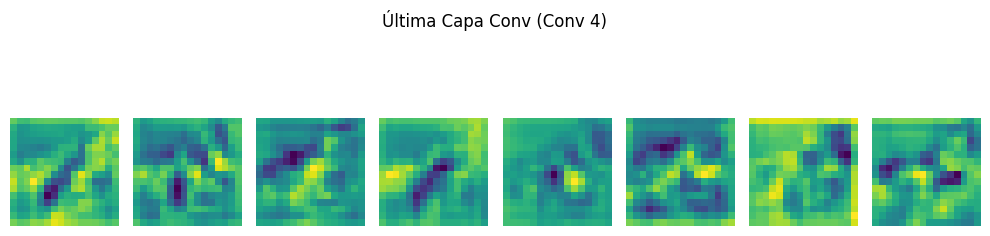


----------------------------------------
CNN-3 | Analizando Imagen 2
----------------------------------------


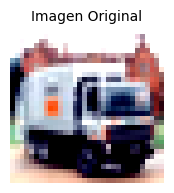

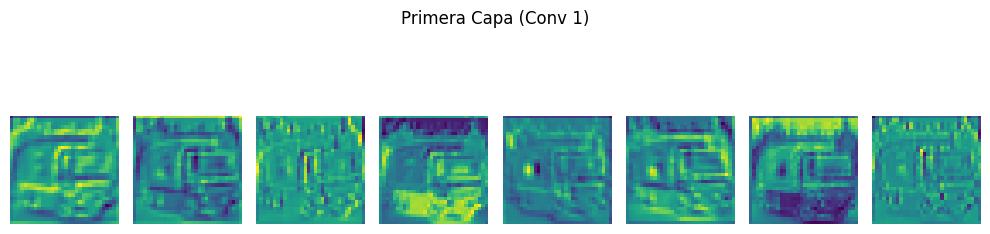

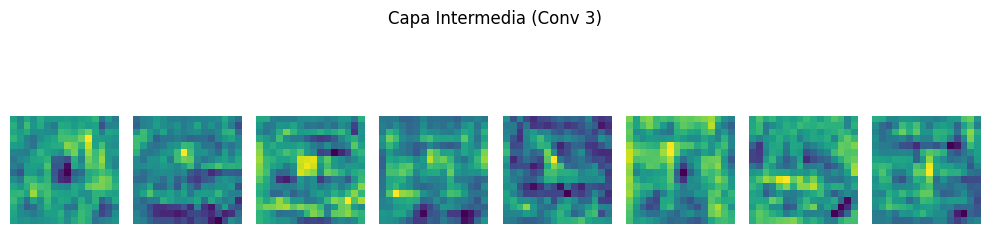

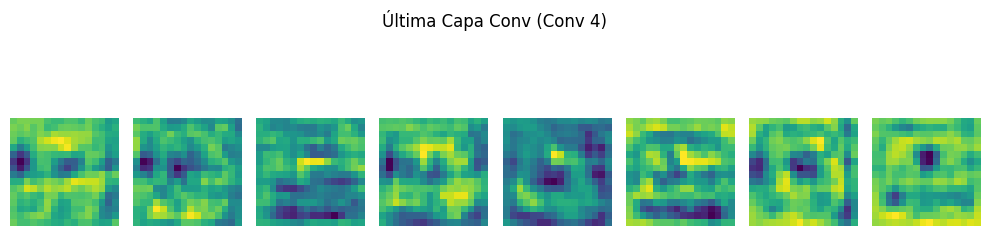



REPORTE DE INTERPRETABILIDAD: CNN-4


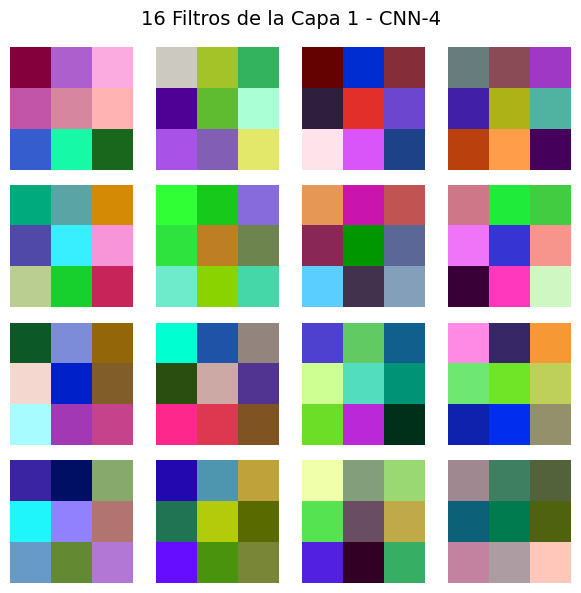


----------------------------------------
CNN-4 | Analizando Imagen 1
----------------------------------------


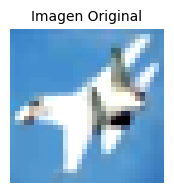

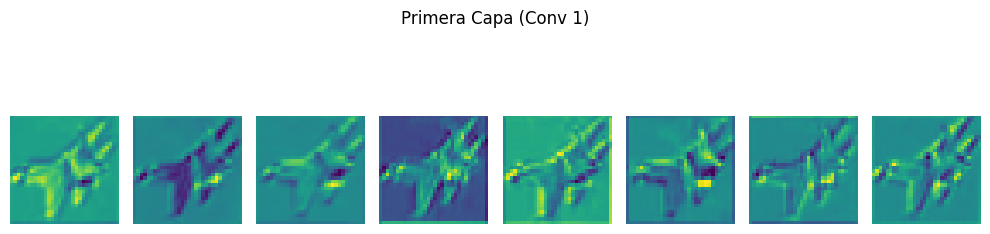

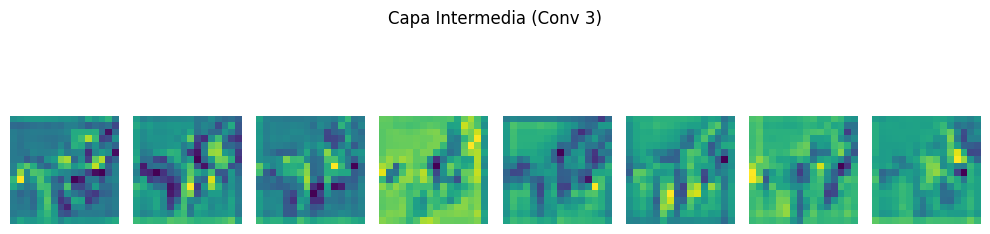

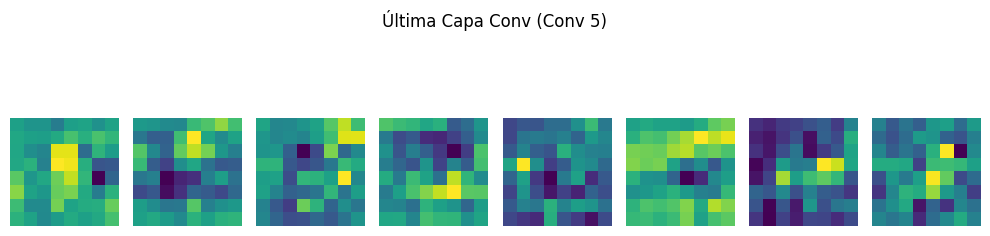


----------------------------------------
CNN-4 | Analizando Imagen 2
----------------------------------------


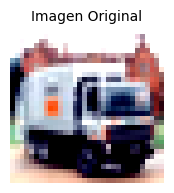

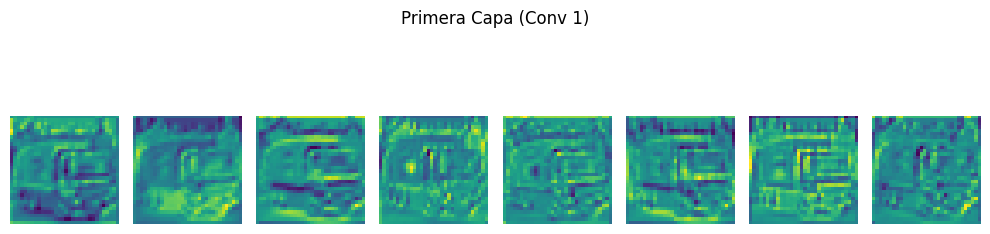

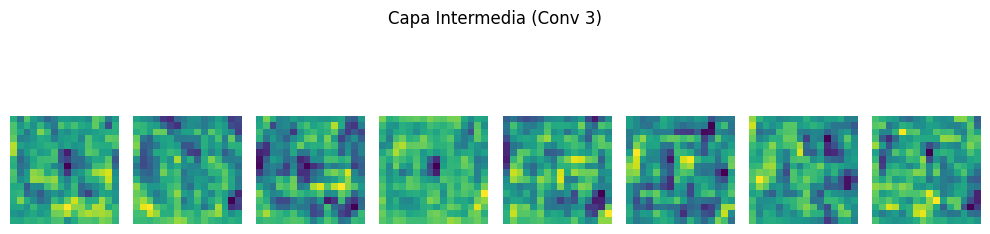

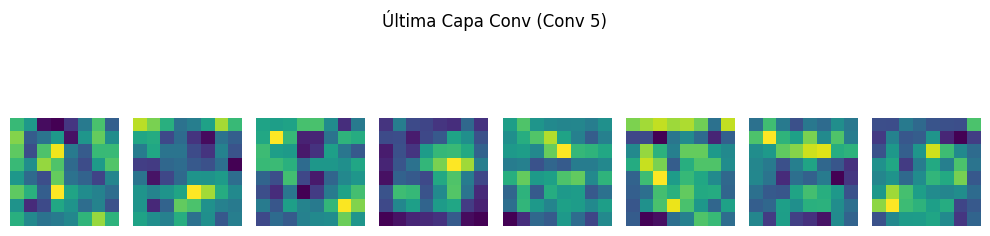



REPORTE DE INTERPRETABILIDAD: CNN-5


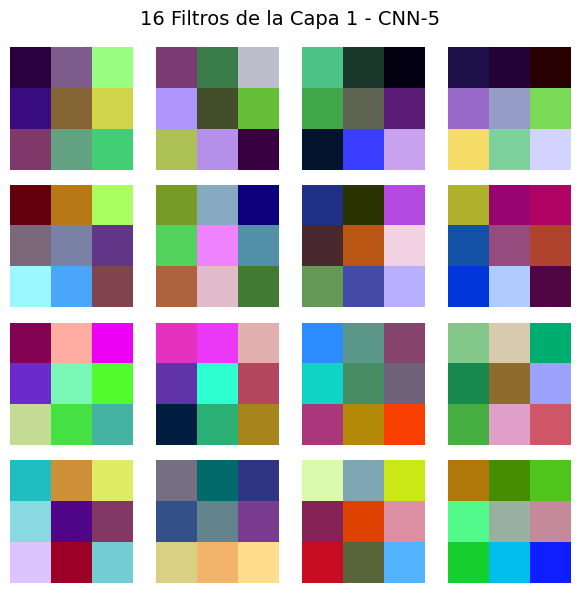


----------------------------------------
CNN-5 | Analizando Imagen 1
----------------------------------------


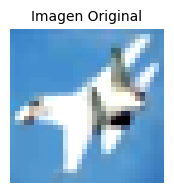

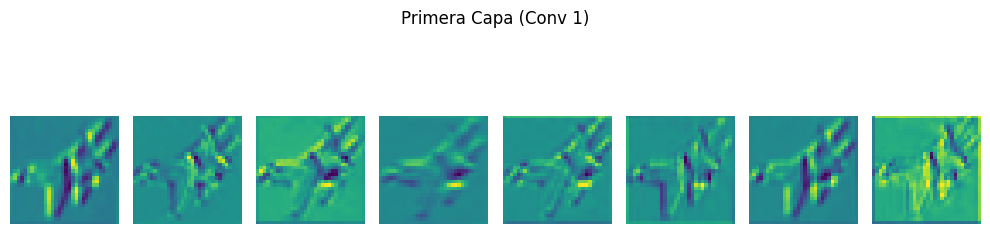

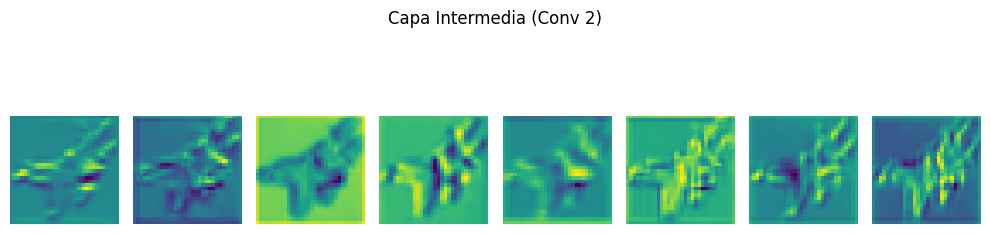

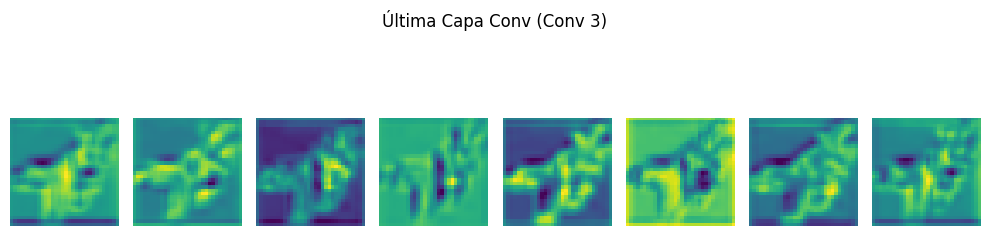


----------------------------------------
CNN-5 | Analizando Imagen 2
----------------------------------------


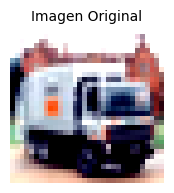

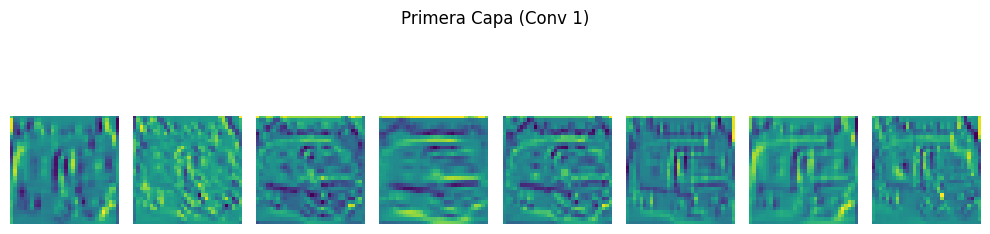

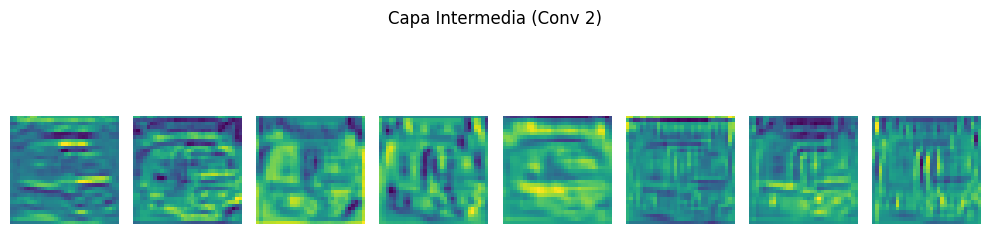

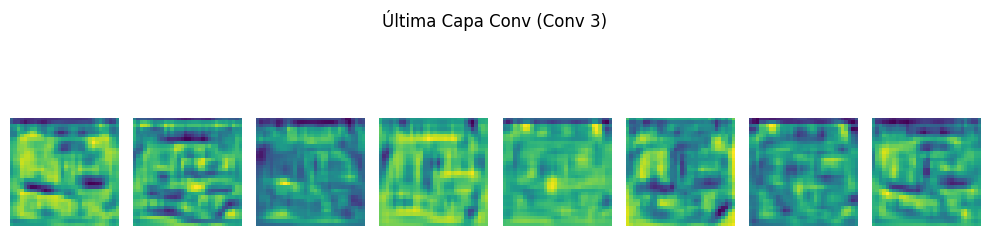

In [124]:
# Tomamos un batch de imágenes de prueba
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Seleccionamos solo las 2 primeras imágenes del batch
sample_images = images[10:12]

for name, model in cnn_models.items():
    print(f"\n\n{'='*60}\nREPORTE DE INTERPRETABILIDAD: {name}\n{'='*60}")
    
    # 1. Visualizar Filtros
    plot_filters(model, name)
    
    # 2. Visualizar Mapas de Activación para las 2 imágenes
    plot_activation_maps(model, name, sample_images)



REPORTE DE INTERPRETABILIDAD: CNN_Eficiente_GAP_Aug


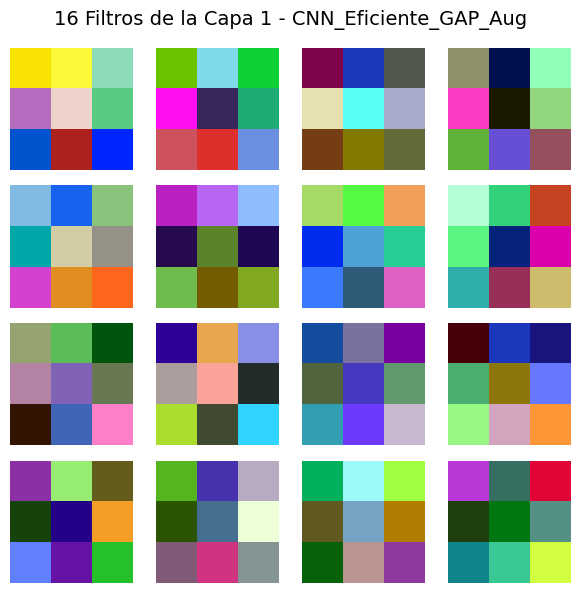


----------------------------------------
CNN_Eficiente_GAP_Aug | Analizando Imagen 1
----------------------------------------


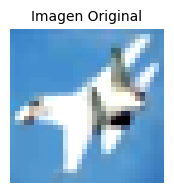

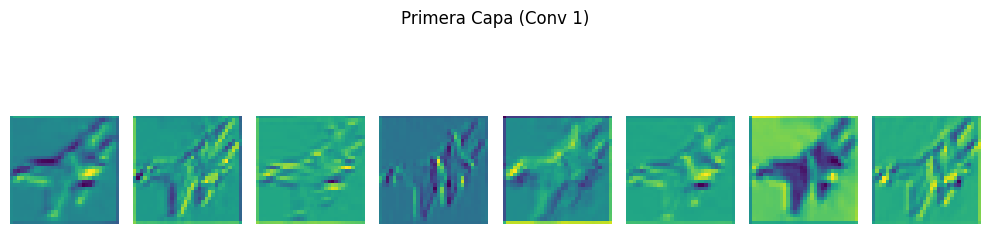

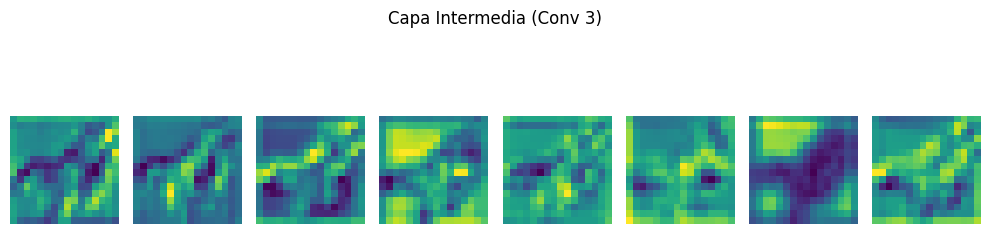

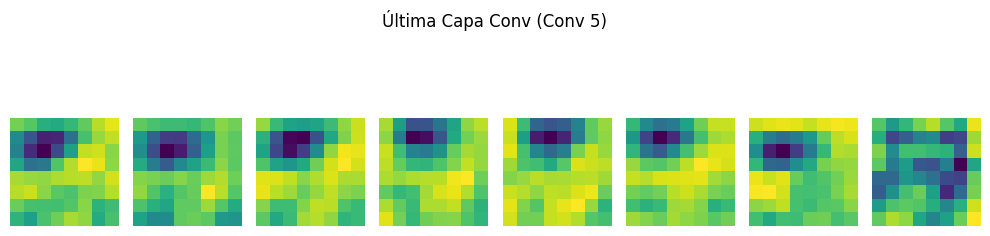


----------------------------------------
CNN_Eficiente_GAP_Aug | Analizando Imagen 2
----------------------------------------


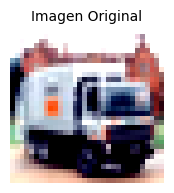

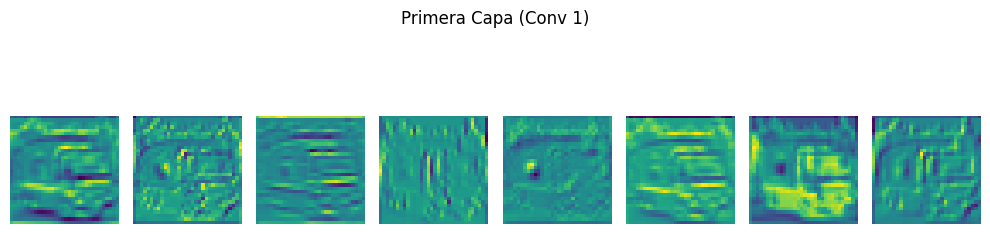

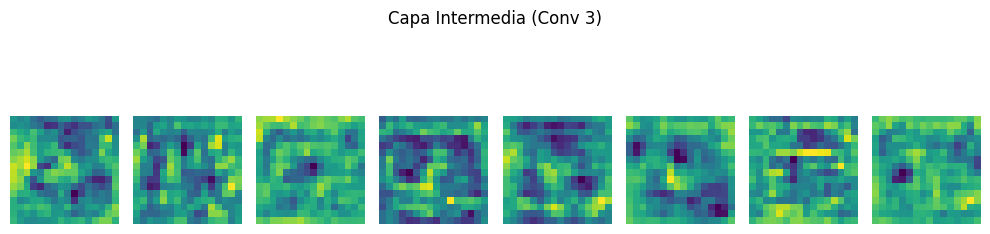

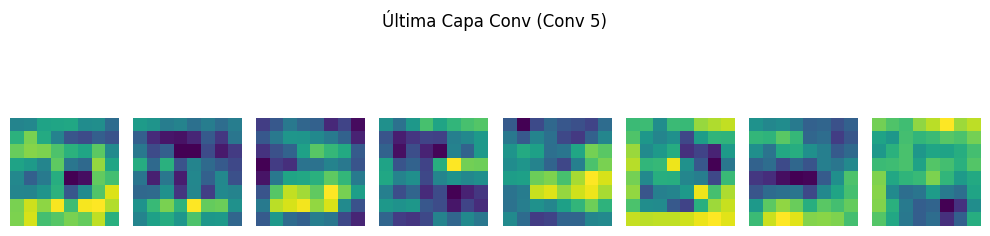


----------------------------------------
CNN_Eficiente_GAP_Aug | Analizando Imagen 3
----------------------------------------


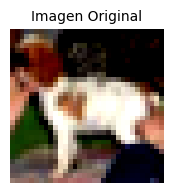

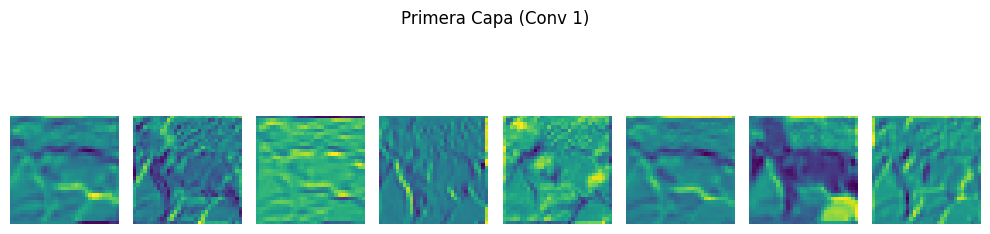

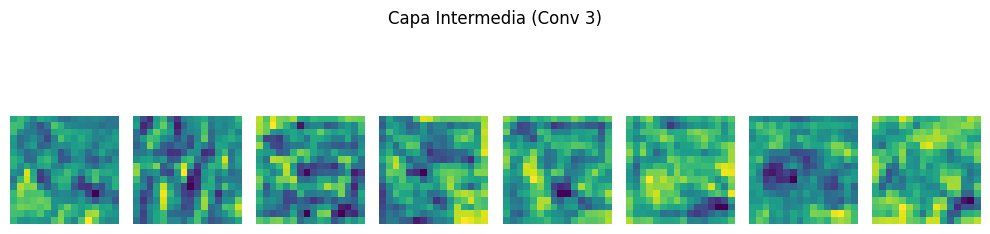

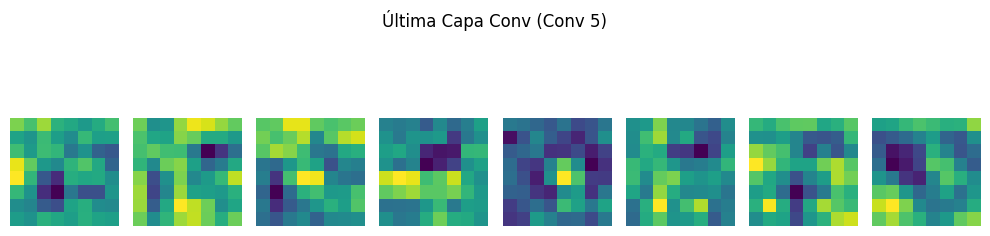


----------------------------------------
CNN_Eficiente_GAP_Aug | Analizando Imagen 4
----------------------------------------


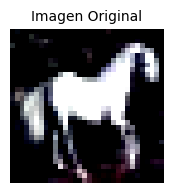

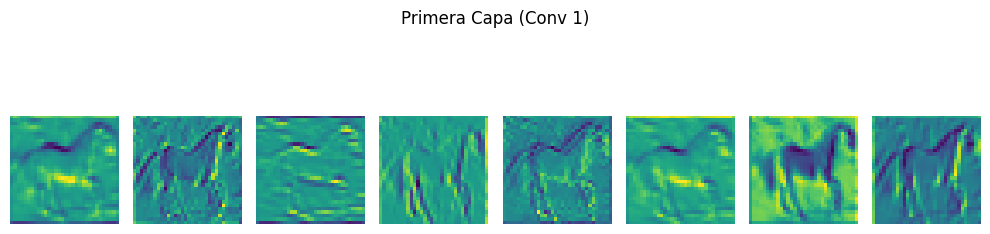

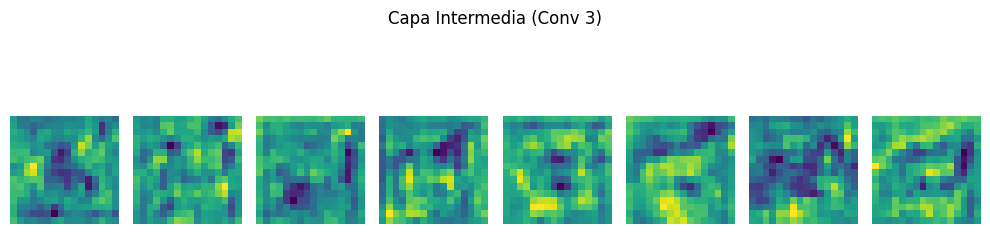

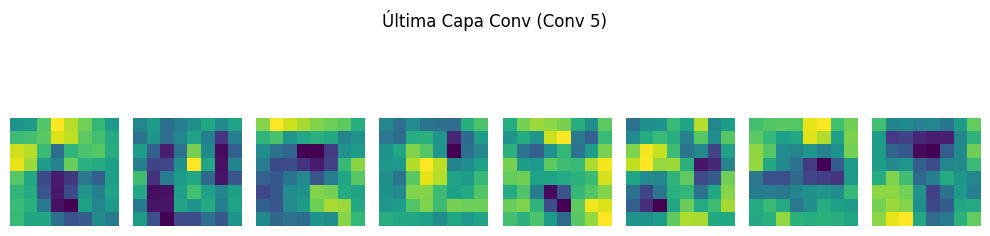

In [87]:
# Tomamos un batch de imágenes de prueba
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Seleccionamos solo las 2 primeras imágenes del batch
sample_images = images[10:14]

for name, model in cnn_models2.items():
    print(f"\n\n{'='*60}\nREPORTE DE INTERPRETABILIDAD: {name}\n{'='*60}")
    
    # 1. Visualizar Filtros
    plot_filters(model, name)
    
    # 2. Visualizar Mapas de Activación para las 2 imágenes
    plot_activation_maps(model, name, sample_images)

## Experimento: permutación fija de píxeles

Aplicaremos una permutación fija a los 3072 valores (C×H×W aplanado), y construiremos:
- Dataset permutado ORIGINAL (para CNN)
- Dataset permutado FLAT (para MLP)

Mantendremos la misma partición .


In [78]:
# Permutación fija (reproducible)
perm_seed = 123
g_perm = torch.Generator().manual_seed(perm_seed)
pixel_perm = torch.randperm(3*32*32, generator=g_perm)

pixel_perm.shape, pixel_perm[:10]


(torch.Size([3072]),
 tensor([1534, 1122, 1264, 1074, 2552, 2280,  960,  899, 2683, 1750]))

In [79]:
def permute_image_tensor(x, pixel_perm):
    # x: (3,32,32) -> flatten(3072) -> permute -> reshape(3,32,32)
    x_flat = torch.flatten(x, start_dim=0)
    x_perm = x_flat[pixel_perm]
    return x_perm.view(3, 32, 32)

# sanity check
x, y = train_full[0]
x_p = permute_image_tensor(x, pixel_perm)
print("Original:", x.shape, "Perm:", x_p.shape, "label:", y)


Original: torch.Size([3, 32, 32]) Perm: torch.Size([3, 32, 32]) label: 6


In [80]:
class PermutedWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, pixel_perm):
        self.base = base_dataset
        self.pixel_perm = pixel_perm

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        x = permute_image_tensor(x, self.pixel_perm)
        return x, y

class PermutedFlatWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, pixel_perm):
        self.base = base_dataset
        self.pixel_perm = pixel_perm

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        x = permute_image_tensor(x, self.pixel_perm)
        x = torch.flatten(x, start_dim=0)
        return x, y

perm_train_full = PermutedWrapper(train_full, pixel_perm)
perm_test_set   = PermutedWrapper(test_set, pixel_perm)

perm_flat_train_full = PermutedFlatWrapper(train_full, pixel_perm)
perm_flat_test_set   = PermutedFlatWrapper(test_set, pixel_perm)

xp, yp = perm_train_full[0]
xpf, ypf = perm_flat_train_full[0]
print("Perm original sample:", xp.shape, yp)
print("Perm flat sample:", xpf.shape, ypf)


Perm original sample: torch.Size([3, 32, 32]) 6
Perm flat sample: torch.Size([3072]) 6


In [81]:
#    - num_workers=0 evita deadlocks por multiprocessing
#    - pin_memory solo si estás usando CUDA
use_cuda = torch.cuda.is_available()
PIN_MEMORY = True if use_cuda else False
NUM_WORKERS = 0   # <- lo más seguro en notebooks

# (Opcional) Para mayor reproducibilidad de la carga
g_loader = torch.Generator().manual_seed(SEED)

perm_test_loader = DataLoader(
    perm_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

perm_flat_test_loader = DataLoader(
    perm_flat_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# 3) Prueba de batch (sin colgarse)
xb, yb = next(iter(perm_test_loader))
xfb, yfb = next(iter(perm_flat_test_loader))

print("Perm batch original:", xb.shape, yb.shape)
print("Perm batch flat:", xfb.shape, yfb.shape)


Perm batch original: torch.Size([256, 3, 32, 32]) torch.Size([256])
Perm batch flat: torch.Size([256, 3072]) torch.Size([256])


In [82]:
# === CELDA DE JUPYTER: EVALUACIÓN CON DATASET PERMUTADO ===
import pandas as pd

print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS CON PÍXELES PERMUTADOS")
print("="*60)

resultados_permutacion = []

# --- 1. EVALUAR LA CNN ---
# Tu modelo CNN retuvo sus pesos en el diccionario original
cnn_model = cnn_models2["CNN_Eficiente_GAP_Aug"]
# Usamos tu función 'evaluate' de la CNN (devuelve loss, accuracy)
cnn_perm_loss, cnn_perm_acc = evaluate(cnn_model, perm_test_loader)

# Si la CNN te regresa decimal (ej. 0.1132), lo multiplicamos por 100. 
# Si ya te regresa 11.32, quítale el "* 100"
if cnn_perm_acc < 1.0: 
    cnn_perm_acc *= 100

resultados_permutacion.append({
    "Arquitectura": "CNN (Eficiente GAP)",
    "Test Accuracy (Imágenes Normales)": df_results.iloc[0]["Test Acc"], 
    "Test Accuracy (Píxeles Permutados)": f"{cnn_perm_acc:.2f}%"
})

# --- 2. EVALUAR EL MLP ---
try:
    mlp_model = resultados[0]["Modelo_Entrenado"]
    
    # El MLP hace el flatten internamente, así que le pasamos el mismo loader
    mlp_perm_loss, mlp_perm_acc = evaluate(mlp_model, perm_test_loader)
    
    resultados_permutacion.append({
        "Arquitectura": "MLP (Red Densa)",
        # ¡EL CAMBIO IMPORTANTE ESTÁ AQUÍ ABAJO! -> Usamos "Test Acc"
        "Test Accuracy (Imágenes Normales)": df_resultados.iloc[0]["Test Acc"],
        "Test Accuracy (Píxeles Permutados)": f"{mlp_perm_acc:.2f}%"
    })
except KeyError:
    print("⚠️ ERROR: No se encontró el modelo MLP en 'resultados'.")
    print("Asegúrate de haber modificado 'train_model_augmented' para que retorne el modelo entrenado.")

# --- 3. MOSTRAR TABLA DE IMPACTO ---
df_impacto = pd.DataFrame(resultados_permutacion)
display(df_impacto)


EVALUACIÓN DE MODELOS CON PÍXELES PERMUTADOS


,Arquitectura,Test Accuracy (Imágenes Normales),Test Accuracy (Píxeles Permutados)
0,CNN (Eficiente GAP),0.8371,10.12%
1,MLP (Red Densa),59.1300,12.30%


========== DISPOSITIVO ==========
Usando dispositivo: cuda


Iniciando entrenamiento (Resize 224x224 en GPU + Transfer Learning puro + SIN Data Augmentation)...


--- Época [1/30] ---


Resultados Época 1 | LR: 0.005000 | Train Loss: 0.8098 | Train Acc: 0.7330 || Val Loss: 0.5694 | Val Acc: 0.8061

--- Época [2/30] ---


Resultados Época 2 | LR: 0.004878 | Train Loss: 0.7015 | Train Acc: 0.7659 || Val Loss: 0.5435 | Val Acc: 0.8140

--- Época [3/30] ---


Resultados Época 3 | LR: 0.004523 | Train Loss: 0.6872 | Train Acc: 0.7703 || Val Loss: 0.5431 | Val Acc: 0.8176

--- Época [4/30] ---


Resultados Época 4 | LR: 0.003969 | Train Loss: 0.6824 | Train Acc: 0.7703 || Val Loss: 0.5277 | Val Acc: 0.8232

--- Época [5/30] ---


...

Resultados Época 26 | LR: 0.002500 | Train Loss: 0.6635 | Train Acc: 0.7765 || Val Loss: 0.5208 | Val Acc: 0.8187

--- Época [27/30] ---


Resultados Época 27 | LR: 0.001727 | Train Loss: 0.6500 | Train Acc: 0.7808 || Val Loss: 0.5158 | Val Acc: 0.8218

--- Época [28/30] ---


Resultados Época 28 | LR: 0.001031 | Train Loss: 0.6336 | Train Acc: 0.7850 || Val Loss: 0.5128 | Val Acc: 0.8224

--- Época [29/30] ---


Resultados Época 29 | LR: 0.000477 | Train Loss: 0.6323 | Train Acc: 0.7845 || Val Loss: 0.5123 | Val Acc: 0.8228

--- Época [30/30] ---


Resultados Época 30 | LR: 0.000122 | Train Loss: 0.6224 | Train Acc: 0.7896 || Val Loss: 0.5116 | Val Acc: 0.8229

========== RESULTADOS FINALES ==========
Accuracy final en Train: 0.7896 (78.96%)
Accuracy final en Test (Val): 0.8229 (82.29%)


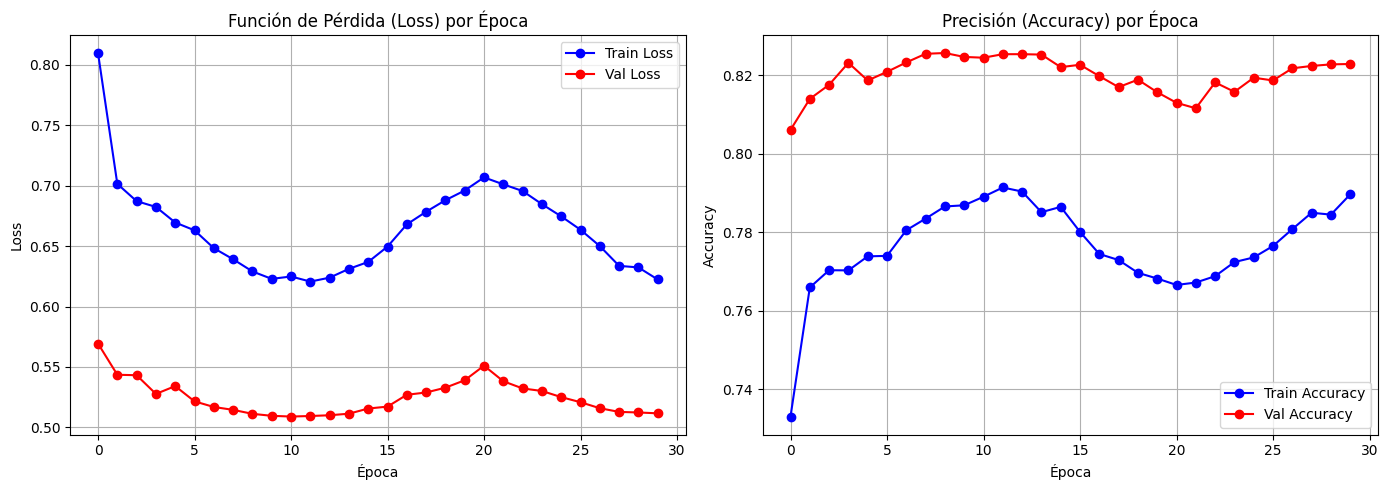

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F  
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
import matplotlib.pyplot as plt
from tqdm import tqdm 

# --- CONFIGURAR DISPOSITIVO (CUDA) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"========== DISPOSITIVO ==========")
print(f"Usando dispositivo: {device}\n")


# Transformaciones BÁSICAS para ENTRENAMIENTO (Quitamos recortes y giros)
transformaciones_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Transformaciones BÁSICAS para VALIDACIÓN
transformaciones_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transformaciones_train)
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transformaciones_val)

# 1. Definir DataLoaders
batch_size = 256 
train_loader = DataLoader(train_full, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# 2. Cargar EfficientNet-B2 preentrenada
weights = EfficientNet_B2_Weights.DEFAULT
model = efficientnet_b2(weights=weights)

# 3. Congelar TODAS las capas base (Transfer Learning puro)
for param in model.parameters():
    param.requires_grad = False

# 4. Modificar la última capa (Clasificador)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 10) 

model = model.to(device)

criterion = nn.CrossEntropyLoss()
# El optimizador SOLO actualizará los pesos de la nueva capa final
optimizer = optim.Adam(model.classifier.parameters(), lr=0.005)

# Bajará el LR progresivamente durante las 10 épocas hasta acercarse a 0
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Inicializar el Scaler para Precisión Mixta (AMP)
scaler = torch.amp.GradScaler('cuda')

epochs = 30 

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("\nIniciando entrenamiento (Resize 224x224 en GPU + Transfer Learning puro + SIN Data Augmentation)...\n")

for epoch in range(epochs):
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"\n--- Época [{epoch+1}/{epochs}] ---")
    
    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    loop_train = tqdm(train_loader, desc="Entrenando", leave=False)
    
    for inputs, labels in loop_train:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        inputs = F.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
        # Actualizar información en la barra de progreso en tiempo real
        loop_train.set_postfix(loss=(running_loss/total_train), acc=(correct_train/total_train))
        
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # Al final del entrenamiento de la época, le decimos que dé un paso
    scheduler.step()
    
    # --- FASE DE VALIDACIÓN ---
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # NUEVO: Barra de progreso para validación
    loop_val = tqdm(val_loader, desc="Validando ", leave=False)
    
    with torch.no_grad():
        for inputs, labels in loop_val:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            inputs = F.interpolate(inputs, size=(224, 224), mode='bilinear', align_corners=False)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    # Imprimir resumen limpio al final de la época (NUEVO: Incluye el LR usado en esta época)
    print(f"Resultados Época {epoch+1} | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

# --- RESULTADOS FINALES Y GRÁFICAS ---
print("\n========== RESULTADOS FINALES ==========")
print(f"Accuracy final en Train: {train_accuracies[-1]:.4f} ({(train_accuracies[-1]*100):.2f}%)")
print(f"Accuracy final en Test (Val): {val_accuracies[-1]:.4f} ({(val_accuracies[-1]*100):.2f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, label='Train Loss', color='blue', marker='o')
ax1.plot(val_losses, label='Val Loss', color='red', marker='o')
ax1.set_title('Función de Pérdida (Loss) por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accuracies, label='Train Accuracy', color='blue', marker='o')
ax2.plot(val_accuracies, label='Val Accuracy', color='red', marker='o')
ax2.set_title('Precisión (Accuracy) por Época')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Usando dispositivo: cuda



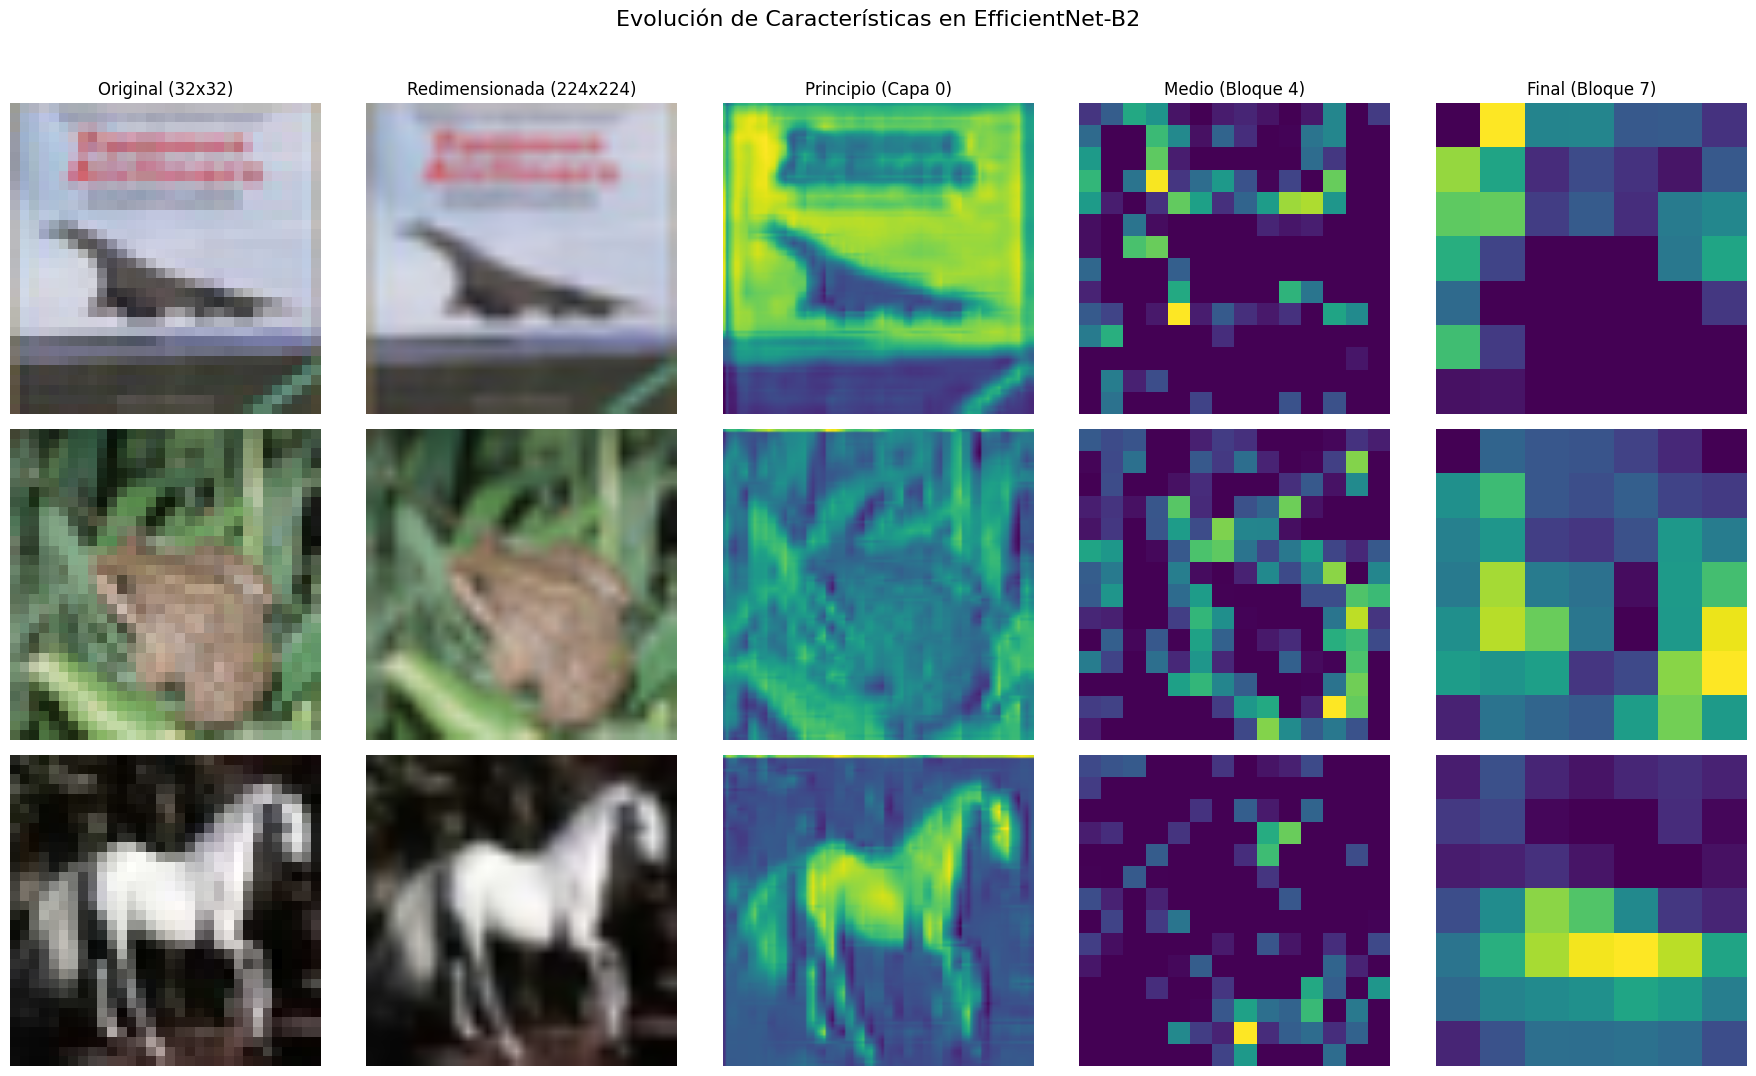

In [85]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURACIÓN INICIAL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}\n")

# Cargar el modelo preentrenado (lo ponemos en modo evaluación)
weights = EfficientNet_B2_Weights.DEFAULT
model = efficientnet_b2(weights=weights).to(device)
model.eval()

# --- 2. PREPARAR 3 IMÁGENES DE PRUEBA ---
transformaciones = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargamos el set de validación
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transformaciones)

# Seleccionamos manualmente 3 imágenes diferentes
indices = [3, 4, 13] 
imagenes_originales = [test_set.data[i] for i in indices] # Imagen original (numpy array)
tensores_entrada = torch.stack([test_set[i][0] for i in indices]).to(device) 

# --- 3. DEFINIR LOS BLOQUES A VISUALIZAR (Hooks) ---
activaciones = {}

def get_activation(name):
    def hook(model, input, output):
        activaciones[name] = output.detach()
    return hook

# Enganchamos sensores en bloques clave:
model.features[0].register_forward_hook(get_activation('Principio (Capa 0)'))
model.features[4].register_forward_hook(get_activation('Medio (Bloque 4)'))
model.features[7].register_forward_hook(get_activation('Final (Bloque 7)'))

# --- 4. PASAR LAS IMÁGENES POR EL MODELO ---
with torch.no_grad():
    # Redimensionamos a 224x224
    tensores_resized = F.interpolate(tensores_entrada, size=(224, 224), mode='bilinear', align_corners=False)
    # Pasamos los tensores por el modelo para activar los hooks
    model(tensores_resized)

# --- NUEVO: FUNCIÓN PARA DES-NORMALIZAR EL TENSOR A IMAGEN ---
def tensor_to_image(tensor):
    """Convierte un tensor normalizado de vuelta a una imagen visible para matplotlib"""
    img = tensor.cpu().clone()
    # Revertir la normalización
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    # Asegurarnos de que los valores estén entre 0 y 1
    img = img.clamp(0, 1)
    # Cambiar de formato (Canales, Alto, Ancho) a (Alto, Ancho, Canales)
    img = img.permute(1, 2, 0).numpy()
    return img

# --- 5. FUNCIÓN PARA GRAFICAR ---
def plot_feature_maps(imagenes_orig, tensores_res, activaciones_dict):
    n_imagenes = len(imagenes_orig)
    etapas = list(activaciones_dict.keys())
    # Ahora tenemos: Original + Resized + N etapas
    n_columnas = len(etapas) + 2 
    
    fig, axes = plt.subplots(n_imagenes, n_columnas, figsize=(18, 3.5 * n_imagenes))
    fig.suptitle("Evolución de Características en EfficientNet-B2", fontsize=16, y=1.02)

    for i in range(n_imagenes):
        # 1. Mostrar imagen original (32x32)
        ax_orig = axes[i, 0]
        ax_orig.imshow(imagenes_orig[i])
        ax_orig.set_title("Original (32x32)" if i == 0 else "")
        ax_orig.axis('off')

        # 2. NUEVO: Mostrar imagen redimensionada (224x224)
        ax_res = axes[i, 1]
        img_resized_visual = tensor_to_image(tensores_res[i])
        ax_res.imshow(img_resized_visual)
        ax_res.set_title("Redimensionada (224x224)" if i == 0 else "")
        ax_res.axis('off')

        # 3. Mostrar los mapas de características
        for j, etapa in enumerate(etapas):
            # Desplazamos el índice por las 2 columnas iniciales
            ax = axes[i, j + 2] 
            
            mapas = activaciones_dict[etapa][i].cpu().numpy()
            mapa_promedio = np.mean(mapas, axis=0)
            
            mapa_promedio = np.maximum(mapa_promedio, 0)
            mapa_promedio = mapa_promedio / np.max(mapa_promedio)
            
            ax.imshow(mapa_promedio, cmap='viridis')
            ax.set_title(etapa if i == 0 else "")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# --- 6. EJECUTAR GRÁFICA ---
plot_feature_maps(imagenes_originales, tensores_resized, activaciones)